# Credit Risk Analysis v2
### Análise Completa de Risco de Crédito com Machine Learning

**Dataset**: UCI Credit Card Default (Taiwan) — 30.000 clientes, 23 features
**Objetivo**: Avaliar e comparar modelos de ML para predição de inadimplência com rigor metodológico equivalente a artigo científico aplicado

---

**Estrutura do Notebook:**
| Fase | Conteúdo |
|------|----------|
| 1 | Análise Exploratória (EDA) |
| 2 | Engenharia de Atributos |
| 3 | Comparação de Modelos |
| 4 | Otimização de Hiperparâmetros |
| 5 | Validação Robusta (Stratified K-Fold) |
| 6 | Testes Estatísticos (McNemar + Paired t-test) |
| 7 | Calibração de Probabilidades |
| 8 | Interpretabilidade Global (Coef / FI / SHAP) |
| 9 | Explicação Individual — 3 Perfis de Clientes |
| 10 | Dashboard / Simulador Interativo |
| ✅ | Conclusões — 7 Questões de Pesquisa Respondidas |
| 📄 | Exportação PDF + PNG + CSV |

**Como rodar**: `Run All` (Kernel → Restart & Run All)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, copy, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, log_loss, brier_score_loss,
    confusion_matrix, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from scipy.stats import ttest_rel, chi2
import xgboost as xgb
import lightgbm as lgb
import shap

Path('outputs/images').mkdir(parents=True, exist_ok=True)
Path('outputs/data').mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42
FIGURES = []
RESULTS_SUMMARY = {}

def save_fig(name):
    path = f'outputs/images/{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=150)
    FIGURES.append({'name': name, 'path': path})
    plt.show()
    plt.close()

print('Bibliotecas carregadas')
print('Diretórios: outputs/images/ e outputs/data/ criados')

Bibliotecas carregadas
Diretórios: outputs/images/ e outputs/data/ criados


## Carregamento dos Dados

In [2]:
df = pd.read_csv('UCI_Credit_Card.csv')
df.rename(columns={'default.payment.next.month': 'default'}, inplace=True)
df.drop(columns=['ID'], errors='ignore', inplace=True)

print(f'Shape: {df.shape}')
print(f'Colunas: {list(df.columns)}')
display(df.head(3))
display(df.dtypes.to_frame('dtype').T)

Shape: (30000, 24)
Colunas: ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default']


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
dtype,float64,int64,int64,int64,int64,int64,int64,int64,int64,int64,...,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64


---
## Fase 1 — Análise Exploratória

Nesta fase investigamos a estrutura do dataset, identificamos padrões, outliers,
missing values e o grau de desbalanceamento da variável alvo.

FASE 1 — ANÁLISE EXPLORATÓRIA

📊 Estatísticas Descritivas:


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.000000,167484.322667,129747.661567,10000.000000,50000.000000,140000.000000,240000.000000,1000000.000000
SEX,30000.000000,1.603733,0.489129,1.000000,1.000000,2.000000,2.000000,2.000000
EDUCATION,30000.000000,1.853133,0.790349,0.000000,1.000000,2.000000,2.000000,6.000000
MARRIAGE,30000.000000,1.551867,0.521970,0.000000,1.000000,2.000000,2.000000,3.000000
AGE,30000.000000,35.485500,9.217904,21.000000,28.000000,34.000000,41.000000,79.000000
PAY_0,30000.000000,-0.016700,1.123802,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_2,30000.000000,-0.133767,1.197186,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_3,30000.000000,-0.166200,1.196868,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_4,30000.000000,-0.220667,1.169139,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_5,30000.000000,-0.266200,1.133187,-2.000000,-1.000000,0.000000,0.000000,8.000000



🔍 Missing Values:
  Nenhum missing value encontrado.


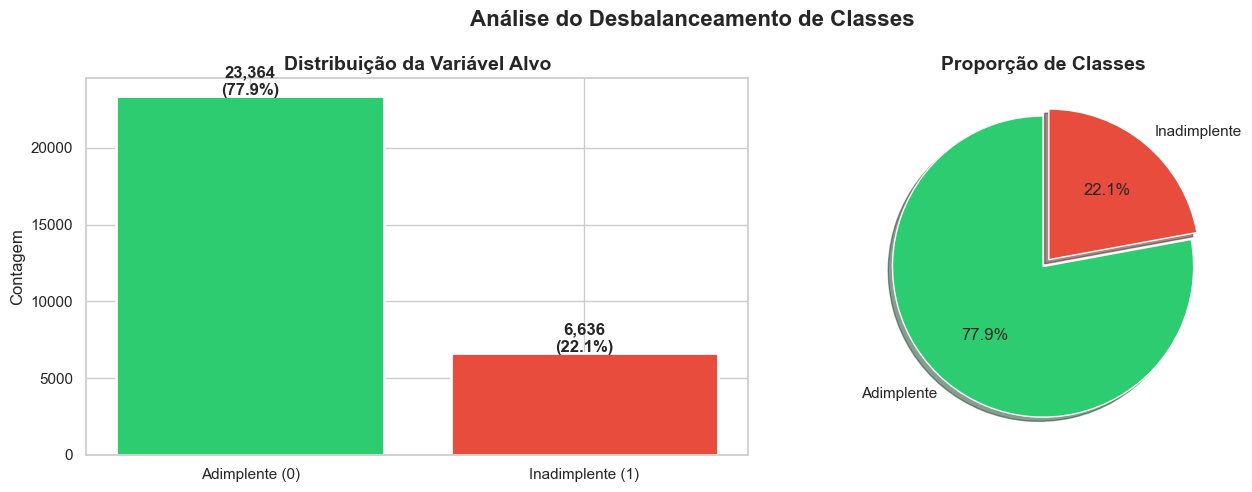

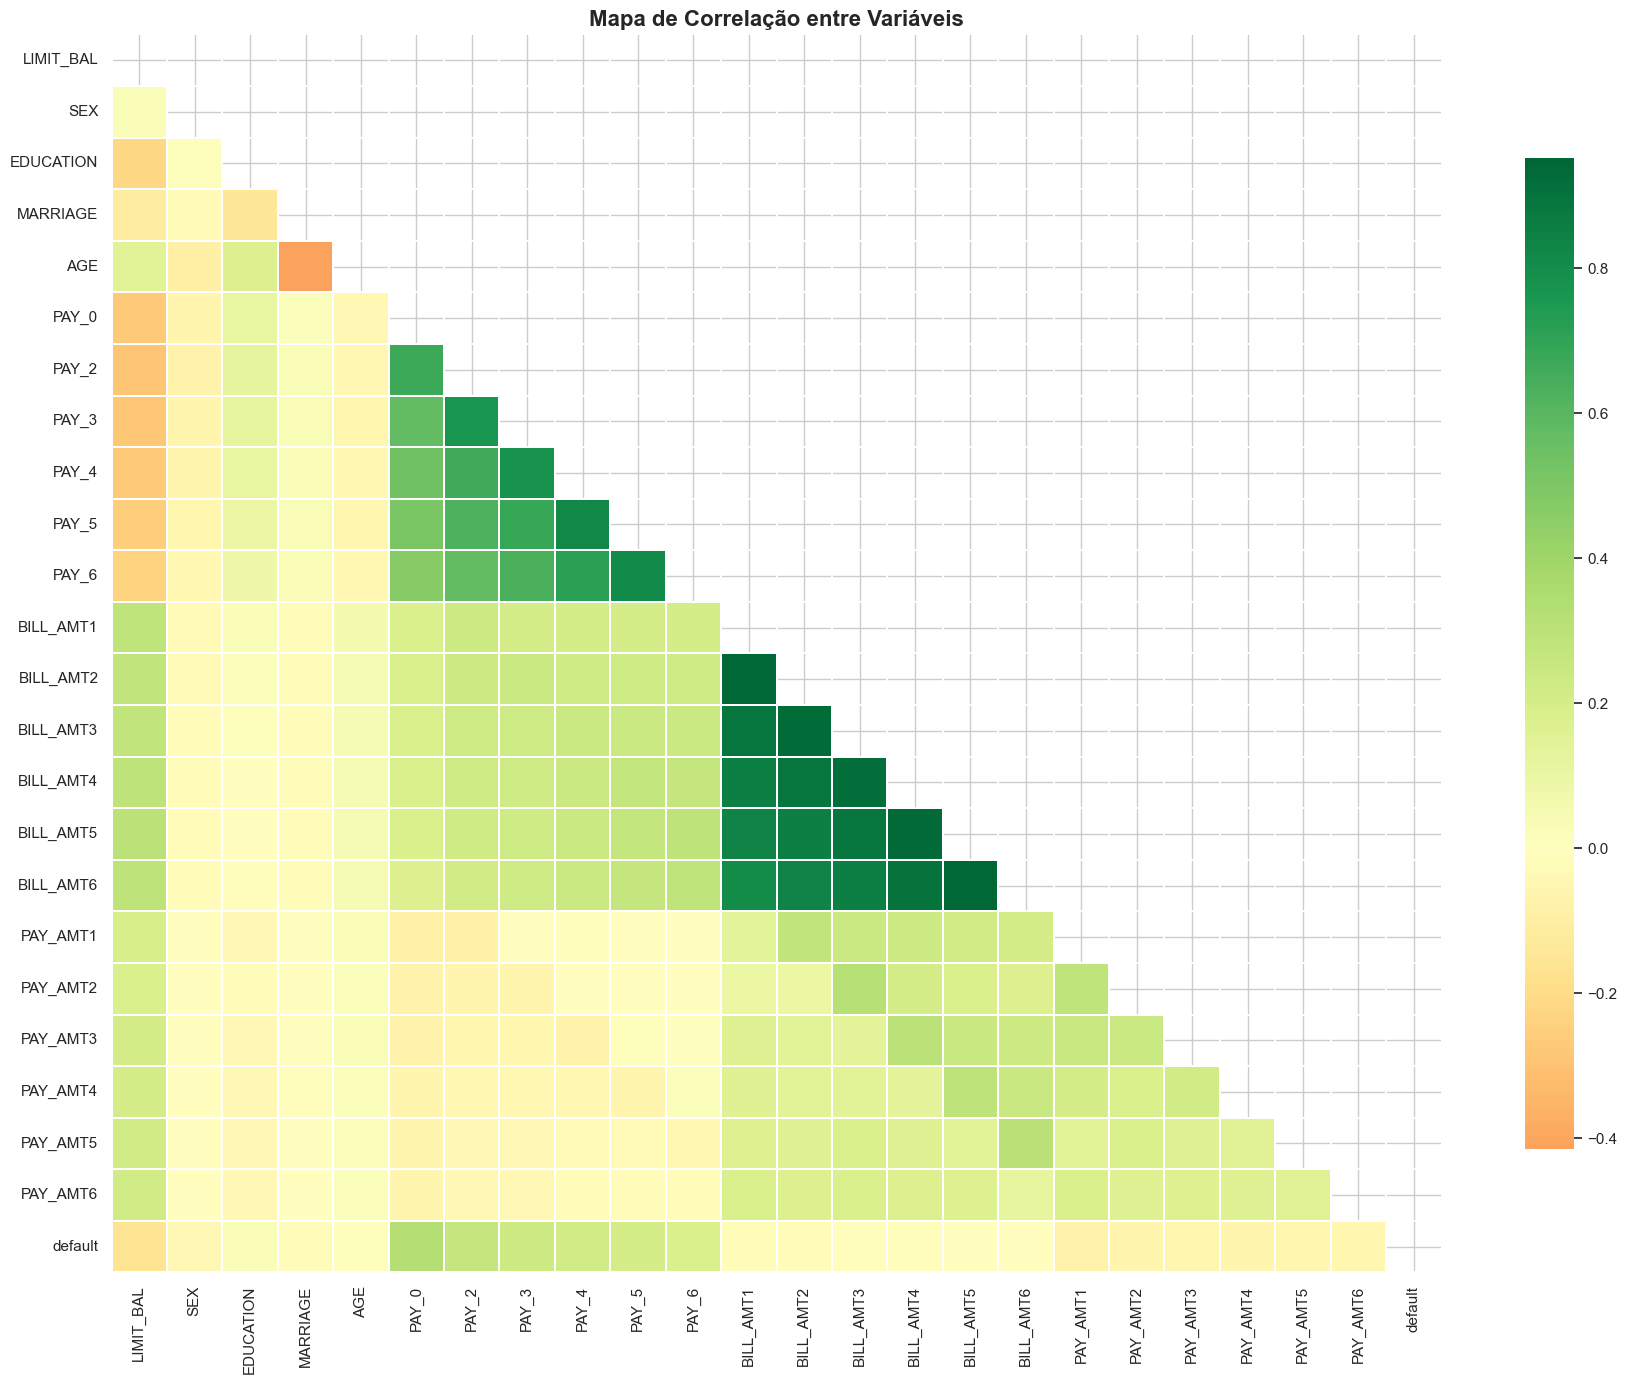

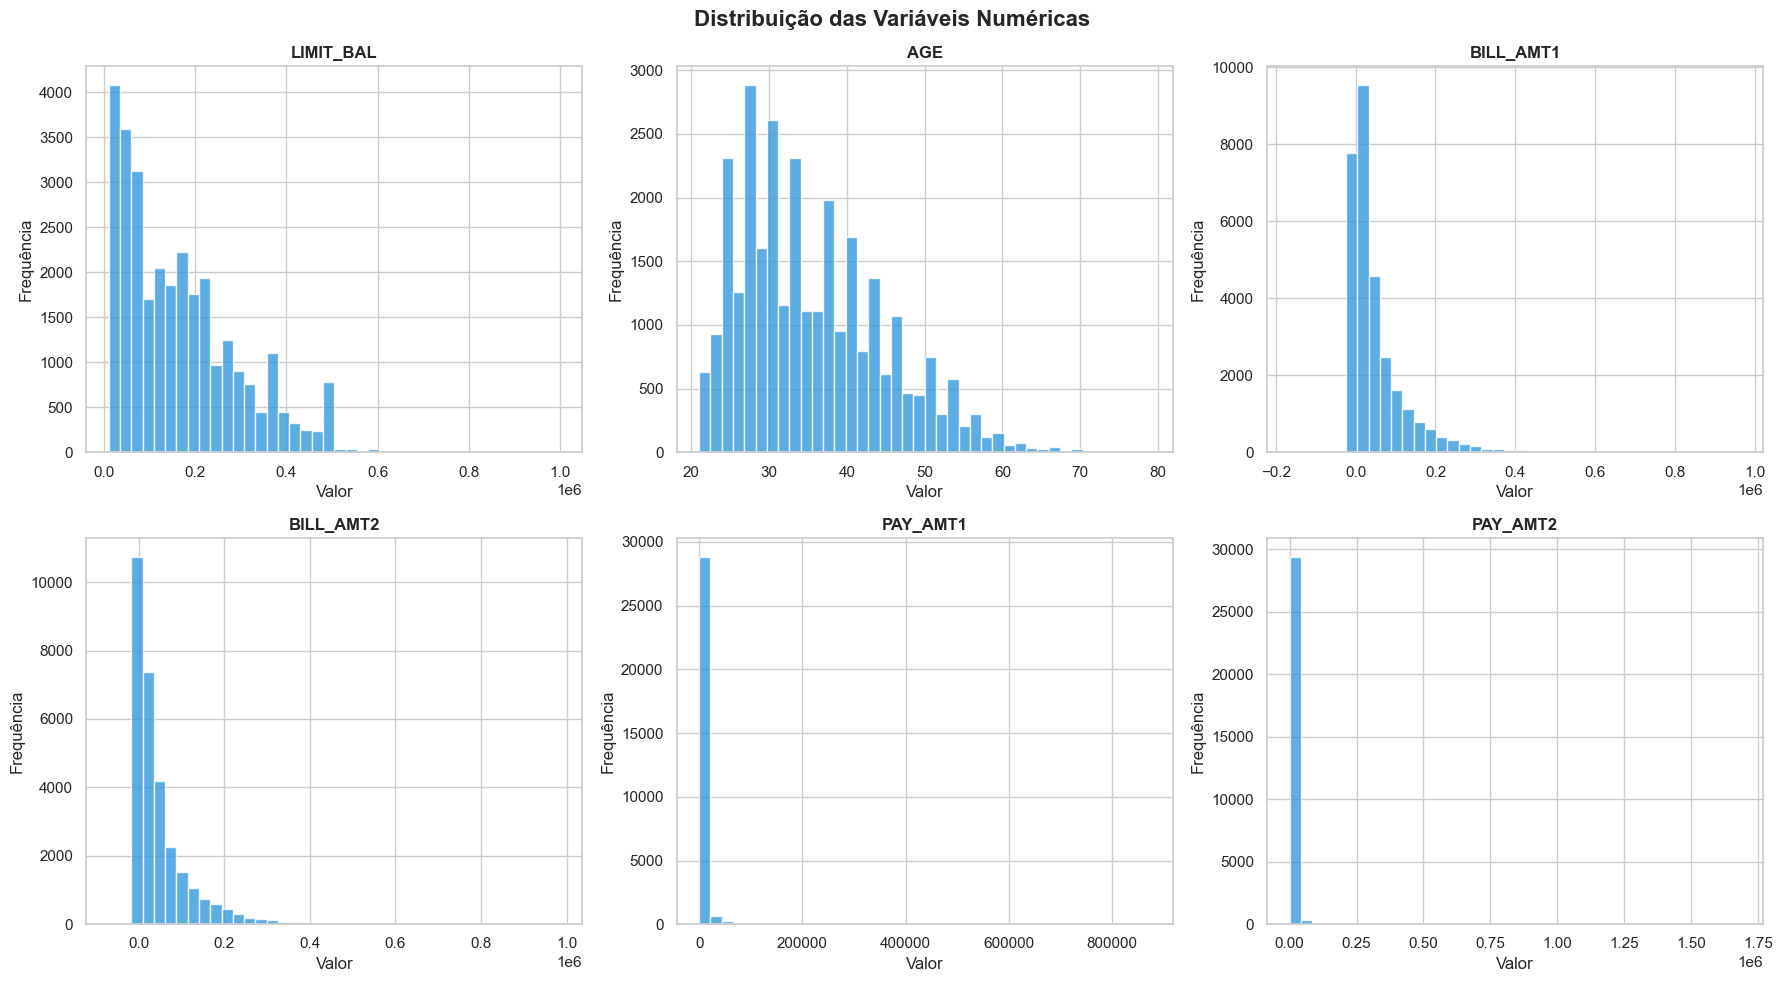

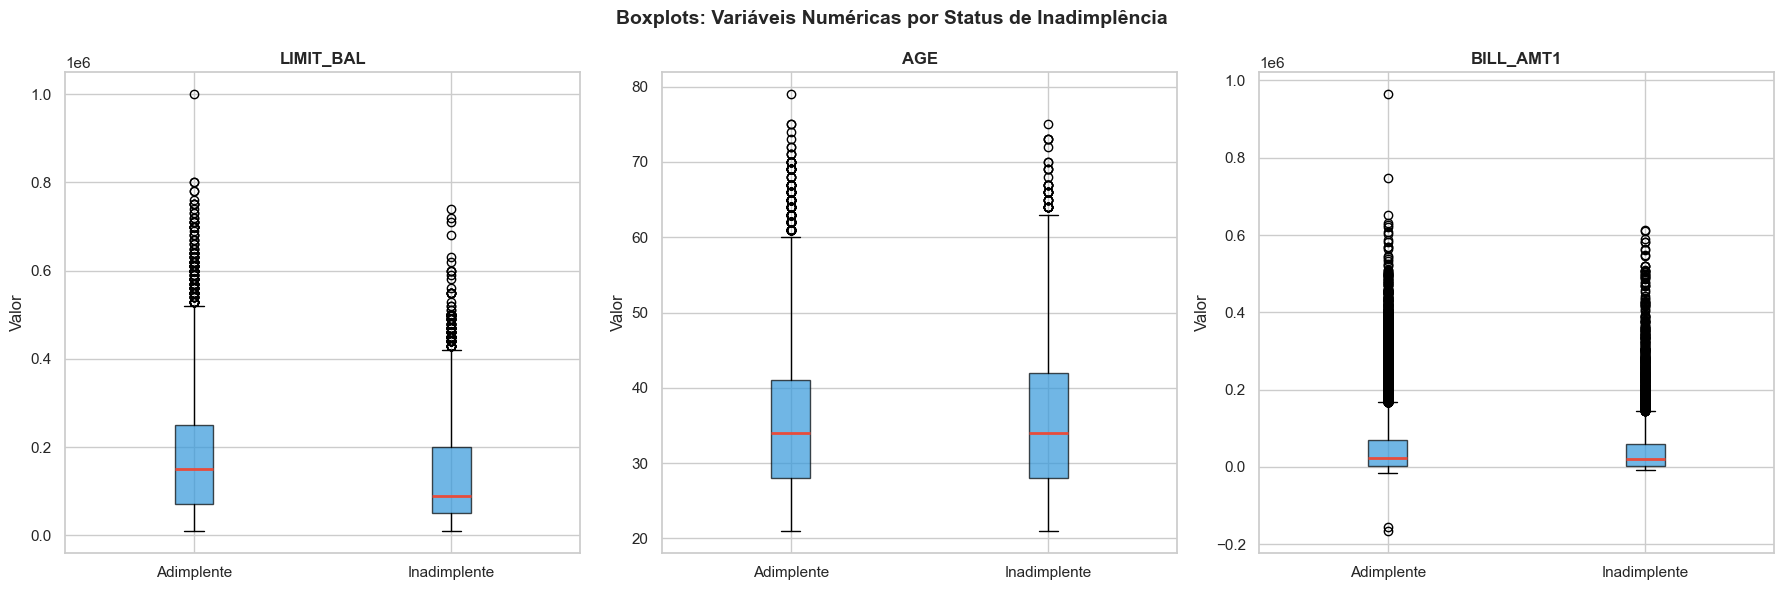

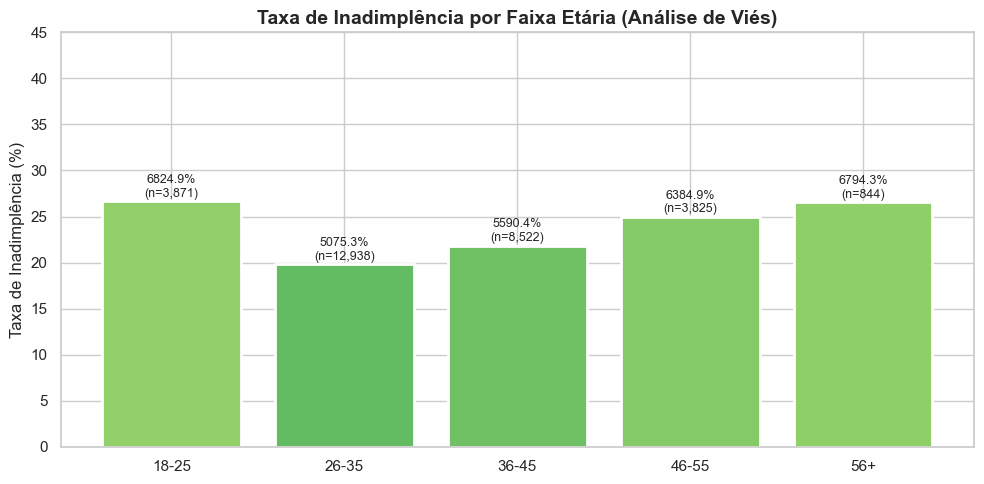

,Faixa Etária,Taxa Inadimplência,N
0,18-25,68.249031,3871
1,26-35,50.752821,12938
2,36-45,55.904248,8522
3,46-55,63.849412,3825
4,56+,67.943128,844



✓ Fase 1 completa


In [3]:
print('=' * 60)
print('FASE 1 — ANÁLISE EXPLORATÓRIA')
print('=' * 60)

# 1.1 Estatísticas descritivas
print('\n📊 Estatísticas Descritivas:')
display(df.describe().T.style.background_gradient(cmap='Blues', subset=['mean','std']))

# 1.2 Missing values
mv = df.isnull().sum()
print('\n🔍 Missing Values:')
print(mv[mv > 0] if mv.sum() > 0 else '  Nenhum missing value encontrado.')

# 1.3 Distribuição da variável alvo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
tc = df['default'].value_counts()
tp = df['default'].value_counts(normalize=True) * 100
axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'], tc.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=2)
axes[0].set_title('Distribuição da Variável Alvo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Contagem')
for i, (v, p) in enumerate(zip(tc.values, tp.values)):
    axes[0].text(i, v + 80, f'{v:,}\n({p:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(tc.values, labels=['Adimplente', 'Inadimplente'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0, 0.06), shadow=True)
axes[1].set_title('Proporção de Classes', fontsize=14, fontweight='bold')
plt.suptitle('Análise do Desbalanceamento de Classes', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig('01_distribuicao_target')
RESULTS_SUMMARY['imbalance_ratio'] = f"{tp.iloc[1]:.1f}% inadimplentes vs {tp.iloc[0]:.1f}% adimplentes"

# 1.4 Heatmap de correlação
plt.figure(figsize=(18, 14))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlGn', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8}, annot=False)
plt.title('Mapa de Correlação entre Variáveis', fontsize=16, fontweight='bold')
plt.tight_layout()
save_fig('02_correlacao_heatmap')

# 1.5 Distribuições das variáveis principais
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'PAY_AMT1', 'PAY_AMT2']):
    df[col].hist(ax=ax, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Valor'); ax.set_ylabel('Frequência')
plt.suptitle('Distribuição das Variáveis Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout(); save_fig('03_distribuicoes_variaveis')

# 1.6 Boxplots por status de inadimplência
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, col in zip(axes, ['LIMIT_BAL', 'AGE', 'BILL_AMT1']):
    data_0 = df[df['default'] == 0][col]
    data_1 = df[df['default'] == 1][col]
    ax.boxplot([data_0, data_1], labels=['Adimplente', 'Inadimplente'],
               patch_artist=True,
               boxprops=dict(facecolor='#3498db', alpha=0.7),
               medianprops=dict(color='#e74c3c', linewidth=2))
    ax.set_title(col, fontweight='bold', fontsize=12)
    ax.set_ylabel('Valor')
plt.suptitle('Boxplots: Variáveis Numéricas por Status de Inadimplência', fontsize=14, fontweight='bold')
plt.tight_layout(); save_fig('04_boxplots_outliers')

# 1.7 Análise de viés por faixa etária (Fairness/Bias check)
df['age_group'] = pd.cut(df['AGE'], bins=[0, 25, 35, 45, 55, 100],
                          labels=['18-25', '26-35', '36-45', '46-55', '56+'])
bias_df = df.groupby('age_group')['default'].agg(['mean', 'count']).reset_index()
bias_df.columns = ['Faixa Etária', 'Taxa Inadimplência', 'N']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(bias_df['Faixa Etária'], bias_df['Taxa Inadimplência'] * 100,
              color=plt.cm.RdYlGn_r(bias_df['Taxa Inadimplência']), edgecolor='white', linewidth=2)
ax.set_title('Taxa de Inadimplência por Faixa Etária (Análise de Viés)', fontsize=14, fontweight='bold')
ax.set_ylabel('Taxa de Inadimplência (%)')
ax.set_ylim(0, 45)
for bar, (_, row) in zip(bars, bias_df.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{row['Taxa Inadimplência']:.1%}\n(n={row['N']:,})", ha='center', fontsize=9)
plt.tight_layout(); save_fig('05_bias_faixa_etaria')
display(bias_df)
df.drop(columns=['age_group'], inplace=True)

print('\n✓ Fase 1 completa')

---
## Fase 2 — Engenharia de Atributos

Criamos 7 features derivadas que capturam padrões temporais e comportamentais do cliente.
Comparamos o desempenho de um modelo base com features originais vs. features engenhadas.

FASE 2 — ENGENHARIA DE ATRIBUTOS

Features criadas:


,Feature,Média,Std,Min,Max
0,mean_delay,-0.1824,0.9822,-2.0000,6.0000
1,max_delay,0.4387,1.3452,-2.0000,8.0000
2,total_payment,31651.3926,60827.6779,0.0000,3764066.0000
3,total_bill,269861.6712,379564.3312,-336259.0000,5263883.0000
4,pay_bill_ratio,21.0397,1255.7714,-589.0000,162000.0000
5,credit_utilization,0.3730,0.3519,-0.2326,5.3640
6,spending_variance,12077.7875,20302.1491,0.0000,647788.0511


  A — Original: AUC = 0.7452
  B — Engenhado: AUC = 0.7533


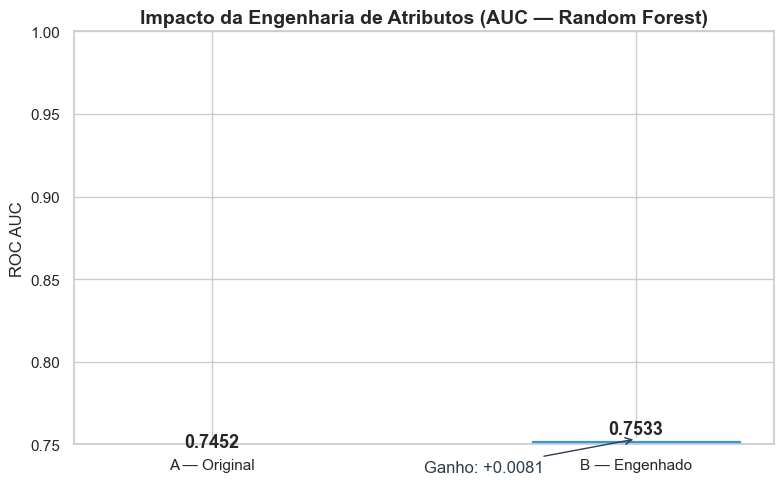


✓ Fase 2 completa — Ganho de AUC com feature engineering: +0.0081


In [4]:
print('=' * 60)
print('FASE 2 — ENGENHARIA DE ATRIBUTOS')
print('=' * 60)

df_eng = df.copy()

pay_cols    = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols   = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
payamt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

df_eng['mean_delay']          = df_eng[pay_cols].mean(axis=1)
df_eng['max_delay']           = df_eng[pay_cols].max(axis=1)
df_eng['total_payment']       = df_eng[payamt_cols].sum(axis=1)
df_eng['total_bill']          = df_eng[bill_cols].sum(axis=1)
df_eng['pay_bill_ratio']      = df_eng['total_payment'] / (df_eng['total_bill'] + 1)
df_eng['credit_utilization']  = df_eng[bill_cols].mean(axis=1) / (df_eng['LIMIT_BAL'] + 1)
df_eng['spending_variance']   = df_eng[bill_cols].std(axis=1)

new_feats = ['mean_delay','max_delay','total_payment','total_bill',
             'pay_bill_ratio','credit_utilization','spending_variance']

feat_summary = pd.DataFrame({
    'Feature': new_feats,
    'Média':   [df_eng[f].mean() for f in new_feats],
    'Std':     [df_eng[f].std()  for f in new_feats],
    'Min':     [df_eng[f].min()  for f in new_feats],
    'Max':     [df_eng[f].max()  for f in new_feats],
})
print('\nFeatures criadas:')
display(feat_summary.style.format({'Média': '{:.4f}', 'Std': '{:.4f}',
                                    'Min': '{:.4f}', 'Max': '{:.4f}'}))

# Comparação A vs B
y = df_eng['default']
results_ab = {}
for scenario, cols_to_use in [('A — Original', df.drop('default',axis=1).columns.tolist()),
                               ('B — Engenhado', df_eng.drop('default',axis=1).columns.tolist())]:
    X_s = df_eng[cols_to_use] if scenario == 'B — Engenhado' else df[cols_to_use]
    Xtr, Xte, ytr, yte = train_test_split(X_s, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
    Xtr_r, ytr_r = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr, ytr)
    ss = StandardScaler()
    Xtr_s = ss.fit_transform(Xtr_r); Xte_s = ss.transform(Xte)
    rf_tmp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
    rf_tmp.fit(Xtr_s, ytr_r)
    auc_val = roc_auc_score(yte, rf_tmp.predict_proba(Xte_s)[:,1])
    results_ab[scenario] = auc_val
    print(f'  {scenario}: AUC = {auc_val:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(list(results_ab.keys()), list(results_ab.values()),
              color=['#95a5a6', '#3498db'], edgecolor='white', linewidth=2, width=0.5)
ax.set_ylim(0.75, 1.0)
ax.set_title('Impacto da Engenharia de Atributos (AUC — Random Forest)', fontsize=14, fontweight='bold')
ax.set_ylabel('ROC AUC')
gain = list(results_ab.values())[1] - list(results_ab.values())[0]
for bar, val in zip(bars, results_ab.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.4f}', ha='center', fontweight='bold', fontsize=13)
ax.annotate(f'Ganho: +{gain:.4f}', xy=(1, list(results_ab.values())[1]),
            xytext=(0.5, list(results_ab.values())[1] - 0.02),
            arrowprops=dict(arrowstyle='->', color='#2c3e50'), fontsize=12, color='#2c3e50')
plt.tight_layout(); save_fig('06_feature_engineering_ab')
RESULTS_SUMMARY['fe_gain'] = gain

print(f'\n✓ Fase 2 completa — Ganho de AUC com feature engineering: +{gain:.4f}')

---
## Fase 3 — Comparação de Modelos

Treinamos 5 modelos (Baseline, Regressão Logística, Random Forest, XGBoost, LightGBM)
e avaliamos com 8 métricas diferentes sobre o mesmo conjunto de teste.

FASE 3 — COMPARAÇÃO DE MODELOS
  Train (após SMOTE): (37382, 30) | {0: 18691, 1: 18691}
  Test: (6000, 30) | {0: 4673, 1: 1327}
  ✓ Baseline             | AUC: 0.5000 | F1: 0.0000
  ✓ Logística            | AUC: 0.6992 | F1: 0.4649
  ✓ Random Forest        | AUC: 0.7545 | F1: 0.5018
  ✓ XGBoost              | AUC: 0.7445 | F1: 0.4814
  ✓ LightGBM             | AUC: 0.7645 | F1: 0.4897


,Modelo,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,Log Loss,Brier
0,Baseline,0.7788,0.0000,0.0000,0.0000,0.5000,0.2212,7.9717,0.2212
1,Logística,0.7015,0.3851,0.5863,0.4649,0.6992,0.4436,0.5921,0.2004
2,Random Forest,0.7978,0.5514,0.4604,0.5018,0.7545,0.5108,0.4778,0.1510
3,XGBoost,0.7907,0.5324,0.4393,0.4814,0.7445,0.5030,0.4925,0.1536
4,LightGBM,0.7972,0.5520,0.4401,0.4897,0.7645,0.5282,0.4567,0.1456


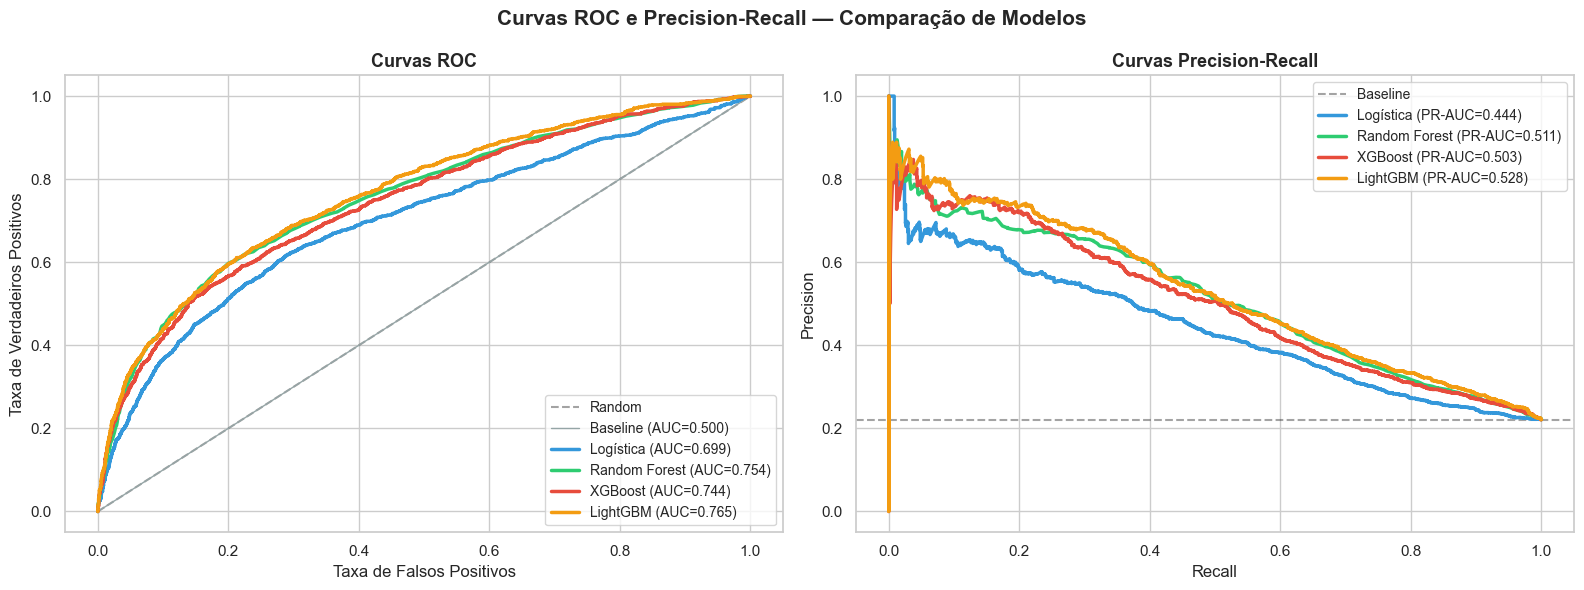

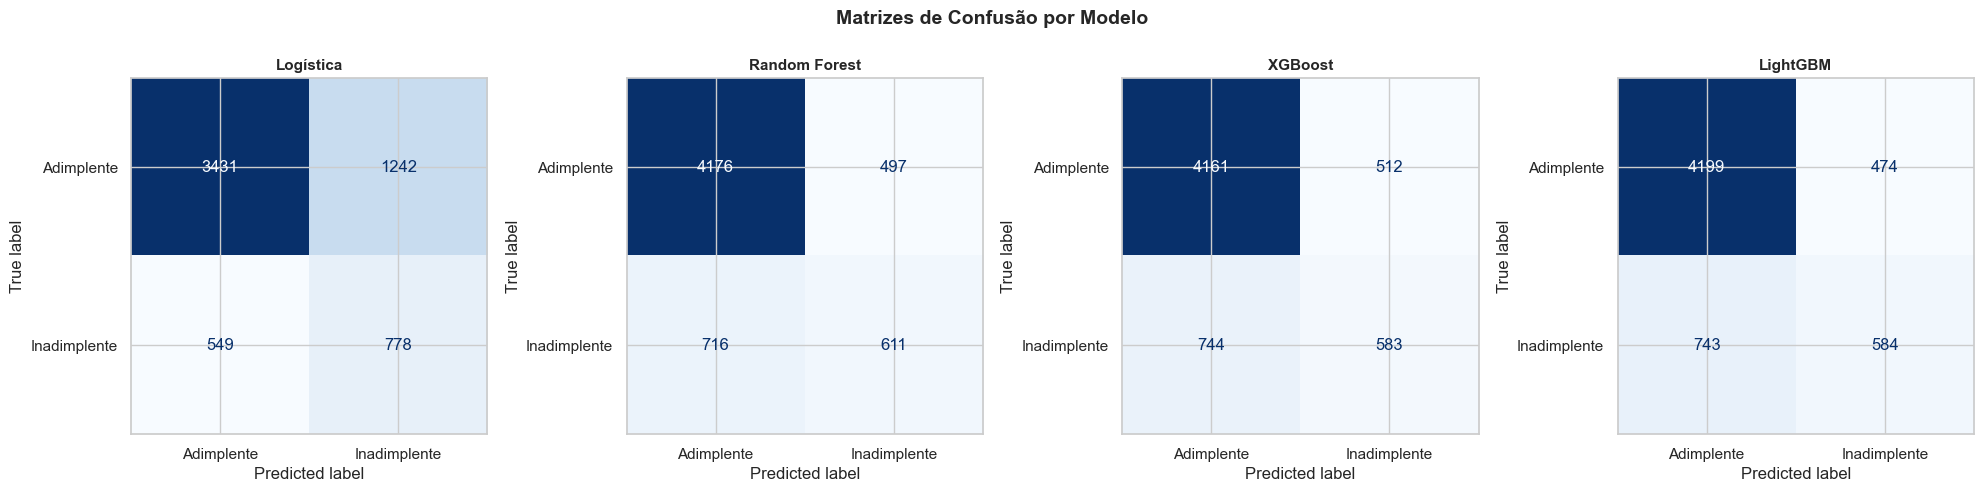


✓ Fase 3 completa — Melhor modelo: LightGBM (AUC=0.7645)


In [5]:
print('=' * 60)
print('FASE 3 — COMPARAÇÃO DE MODELOS')
print('=' * 60)

X = df_eng.drop('default', axis=1)
y = df_eng['default']
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

sm = SMOTE(random_state=RANDOM_STATE)
X_res, y_res = sm.fit_resample(X_train, y_train)

scaler = StandardScaler()
X_res_s  = scaler.fit_transform(X_res)
X_test_s = scaler.transform(X_test)

print(f'  Train (após SMOTE): {X_res_s.shape} | {pd.Series(y_res).value_counts().to_dict()}')
print(f'  Test: {X_test_s.shape} | {y_test.value_counts().to_dict()}')

models_def = {
    'Baseline':      DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE),
    'Logística':     LogisticRegression(max_iter=1000, C=0.1, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':       xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                        eval_metric='logloss', verbosity=0),
    'LightGBM':      lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1),
}

trained_models = {}
metrics_list = []

for name, model in models_def.items():
    model.fit(X_res_s, y_res)
    trained_models[name] = model
    y_pred  = model.predict(X_test_s)
    y_proba = model.predict_proba(X_test_s)[:,1]
    row = {
        'Modelo':    name,
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall':    recall_score(y_test, y_pred, zero_division=0),
        'F1':        f1_score(y_test, y_pred, zero_division=0),
        'ROC AUC':   roc_auc_score(y_test, y_proba),
        'PR AUC':    average_precision_score(y_test, y_proba),
        'Log Loss':  log_loss(y_test, model.predict_proba(X_test_s)),
        'Brier':     brier_score_loss(y_test, y_proba),
    }
    metrics_list.append(row)
    print(f'  ✓ {name:20s} | AUC: {row["ROC AUC"]:.4f} | F1: {row["F1"]:.4f}')

df_metrics = pd.DataFrame(metrics_list)
df_metrics.to_csv('outputs/data/tabela_modelos.csv', index=False)
display(df_metrics.style.format({c: '{:.4f}' for c in df_metrics.columns if c != 'Modelo'})
        .background_gradient(cmap='RdYlGn', subset=['ROC AUC','F1','Recall','PR AUC'])
        .background_gradient(cmap='RdYlGn_r', subset=['Log Loss','Brier']))

# ROC Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot([0,1],[0,1],'k--',alpha=0.4,label='Random')
colors_m = ['#95a5a6','#3498db','#2ecc71','#e74c3c','#f39c12']
for (name, model), color in zip(trained_models.items(), colors_m):
    proba = model.predict_proba(X_test_s)[:,1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    lw = 2.5 if name != 'Baseline' else 1
    axes[0].plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC={auc:.3f})')
axes[0].set_title('Curvas ROC', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Taxa de Falsos Positivos'); axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].legend(loc='lower right', fontsize=10)

# PR Curves
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.4, label='Baseline')
for (name, model), color in zip(trained_models.items(), colors_m):
    if name == 'Baseline': continue
    proba = model.predict_proba(X_test_s)[:,1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    pr_auc = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2.5, label=f'{name} (PR-AUC={pr_auc:.3f})')
axes[1].set_title('Curvas Precision-Recall', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(loc='upper right', fontsize=10)
plt.suptitle('Curvas ROC e Precision-Recall — Comparação de Modelos', fontsize=15, fontweight='bold')
plt.tight_layout(); save_fig('07_roc_pr_curves')

# Confusion Matrices
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, ['Logística','Random Forest','XGBoost','LightGBM']):
    model = trained_models[name]
    cm = confusion_matrix(y_test, model.predict(X_test_s))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Adimplente','Inadimplente'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontweight='bold', fontsize=11)
plt.suptitle('Matrizes de Confusão por Modelo', fontsize=14, fontweight='bold')
plt.tight_layout(); save_fig('08_confusion_matrices')

RESULTS_SUMMARY['best_model_auc'] = df_metrics.loc[df_metrics['ROC AUC'].idxmax(), 'Modelo']
RESULTS_SUMMARY['best_auc'] = df_metrics['ROC AUC'].max()

print(f'\n✓ Fase 3 completa — Melhor modelo: {RESULTS_SUMMARY["best_model_auc"]} (AUC={RESULTS_SUMMARY["best_auc"]:.4f})')

---
## Fase 4 — Otimização de Hiperparâmetros

Utilizamos `RandomizedSearchCV` para otimizar os 3 modelos ensemble.
Comparamos AUC antes e depois da otimização.

FASE 4 — OTIMIZAÇÃO DE HIPERPARÂMETROS
RF melhor params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
XGB melhor params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.5, 'colsample_bytree': 1.0}
LGB melhor params: {'subsample': 0.7, 'num_leaves': 80, 'n_estimators': 300, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.05}


,Modelo,AUC Antes,AUC Depois,Ganho
0,Random Forest,0.7545,0.7556,0.0011
1,XGBoost,0.7445,0.7438,-0.0007
2,LightGBM,0.7645,0.7646,0.0001


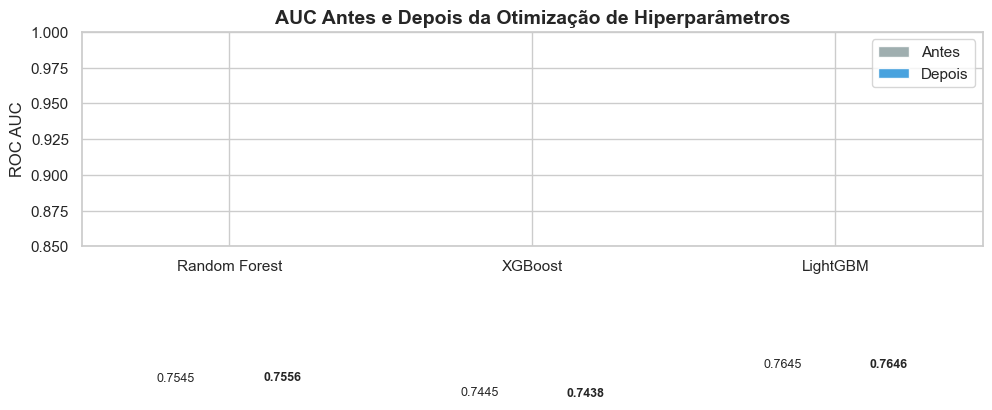


✓ Fase 4 completa


In [6]:
print('=' * 60)
print('FASE 4 — OTIMIZAÇÃO DE HIPERPARÂMETROS')
print('=' * 60)

auc_before = {
    'Random Forest': roc_auc_score(y_test, trained_models['Random Forest'].predict_proba(X_test_s)[:,1]),
    'XGBoost':       roc_auc_score(y_test, trained_models['XGBoost'].predict_proba(X_test_s)[:,1]),
    'LightGBM':      roc_auc_score(y_test, trained_models['LightGBM'].predict_proba(X_test_s)[:,1]),
}

# RF
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    {'n_estimators':[100,200,300], 'max_depth':[None,10,20,30],
     'min_samples_split':[2,5,10], 'max_features':['sqrt','log2'],
     'min_samples_leaf':[1,2,4]},
    n_iter=20, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
rf_search.fit(X_res_s, y_res)
best_rf = rf_search.best_estimator_
print(f'RF melhor params: {rf_search.best_params_}')

# XGB
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss', verbosity=0),
    {'n_estimators':[100,200,300], 'max_depth':[3,5,7],
     'learning_rate':[0.01,0.05,0.1,0.2], 'subsample':[0.7,0.8,1.0],
     'colsample_bytree':[0.7,0.8,1.0], 'gamma':[0,0.1,0.5]},
    n_iter=20, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
xgb_search.fit(X_res_s, y_res)
best_xgb = xgb_search.best_estimator_
print(f'XGB melhor params: {xgb_search.best_params_}')

# LGB
lgb_search = RandomizedSearchCV(
    lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    {'n_estimators':[100,200,300], 'max_depth':[-1,5,10,15],
     'learning_rate':[0.01,0.05,0.1], 'num_leaves':[31,50,80,100],
     'min_child_samples':[20,50,100], 'subsample':[0.7,0.8,1.0]},
    n_iter=20, scoring='roc_auc', cv=3, random_state=RANDOM_STATE, n_jobs=-1, verbose=0)
lgb_search.fit(X_res_s, y_res)
best_lgb = lgb_search.best_estimator_
print(f'LGB melhor params: {lgb_search.best_params_}')

auc_after = {
    'Random Forest': roc_auc_score(y_test, best_rf.predict_proba(X_test_s)[:,1]),
    'XGBoost':       roc_auc_score(y_test, best_xgb.predict_proba(X_test_s)[:,1]),
    'LightGBM':      roc_auc_score(y_test, best_lgb.predict_proba(X_test_s)[:,1]),
}

tuning_df = pd.DataFrame({
    'Modelo':       list(auc_before.keys()),
    'AUC Antes':    list(auc_before.values()),
    'AUC Depois':   list(auc_after.values()),
    'Ganho':        [auc_after[m] - auc_before[m] for m in auc_before],
})
tuning_df.to_csv('outputs/data/tabela_otimizacao.csv', index=False)
display(tuning_df.style.format({c: '{:.4f}' for c in tuning_df.columns if c != 'Modelo'})
        .background_gradient(cmap='RdYlGn', subset=['Ganho']))

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, tuning_df['AUC Antes'], w, label='Antes',  color='#95a5a6', alpha=0.9)
ax.bar(x + w/2, tuning_df['AUC Depois'],w, label='Depois', color='#3498db', alpha=0.9)
for i, (b, a) in enumerate(zip(tuning_df['AUC Antes'], tuning_df['AUC Depois'])):
    ax.text(i - w/2, b + 0.001, f'{b:.4f}', ha='center', fontsize=9)
    ax.text(i + w/2, a + 0.001, f'{a:.4f}', ha='center', fontsize=9, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(tuning_df['Modelo'])
ax.set_ylim(0.85, 1.0)
ax.set_title('AUC Antes e Depois da Otimização de Hiperparâmetros', fontsize=14, fontweight='bold')
ax.set_ylabel('ROC AUC'); ax.legend()
plt.tight_layout(); save_fig('09_otimizacao_hiperparametros')

trained_models['Random Forest'] = best_rf
trained_models['XGBoost']       = best_xgb
trained_models['LightGBM']      = best_lgb

print('\n✓ Fase 4 completa')

---
## Fase 5 — Validação Robusta (Stratified K-Fold)

Validação com 10 folds estratificados para avaliar a estabilidade dos modelos.
Calculamos média e desvio padrão do AUC em todos os folds.

FASE 5 — VALIDAÇÃO ROBUSTA (STRATIFIED K-FOLD)
  ✓ Logística            | AUC: 0.7383 ± 0.0114
  ✓ Random Forest        | AUC: 0.7709 ± 0.0089
  ✓ XGBoost              | AUC: 0.7592 ± 0.0094
  ✓ LightGBM             | AUC: 0.7770 ± 0.0099


,Logística,Random Forest,XGBoost,LightGBM
Fold 1,0.7314,0.7703,0.7614,0.7763
Fold 2,0.7512,0.7877,0.7772,0.7952
Fold 3,0.7163,0.7601,0.7513,0.7584
Fold 4,0.7482,0.7698,0.7636,0.7769
Fold 5,0.7228,0.7579,0.7487,0.7665
Fold 6,0.7540,0.7725,0.7557,0.7806
Fold 7,0.7390,0.7805,0.7641,0.7870
Fold 8,0.7380,0.7783,0.7706,0.7819
Fold 9,0.7392,0.7695,0.7530,0.7779
Fold 10,0.7426,0.7627,0.7466,0.7696


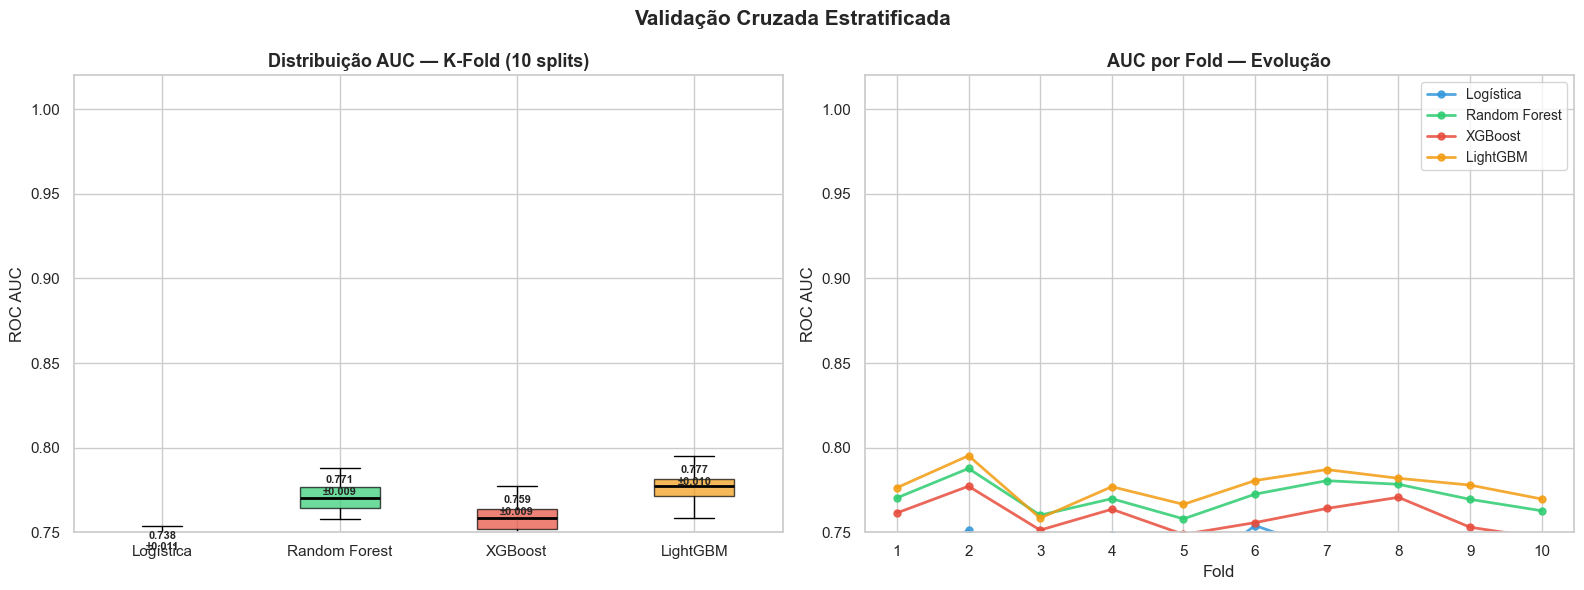


✓ Fase 5 completa


In [7]:
print('=' * 60)
print('FASE 5 — VALIDAÇÃO ROBUSTA (STRATIFIED K-FOLD)')
print('=' * 60)

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
X_full = X.values; y_full = y.values

cv_models = {
    'Logística':     LogisticRegression(max_iter=1000, C=0.1, random_state=RANDOM_STATE),
    'Random Forest': best_rf,
    'XGBoost':       best_xgb,
    'LightGBM':      best_lgb,
}

kfold_results = {}

for name, model_cv in cv_models.items():
    fold_aucs = []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_full, y_full)):
        X_tr_f, X_val_f = X_full[train_idx], X_full[val_idx]
        y_tr_f, y_val_f = y_full[train_idx], y_full[val_idx]
        X_res_f, y_res_f = SMOTE(random_state=RANDOM_STATE).fit_resample(X_tr_f, y_tr_f)
        ss_f = StandardScaler()
        X_tr_fs = ss_f.fit_transform(X_res_f)
        X_val_fs = ss_f.transform(X_val_f)
        m = copy.deepcopy(model_cv)
        m.fit(X_tr_fs, y_res_f)
        fold_aucs.append(roc_auc_score(y_val_f, m.predict_proba(X_val_fs)[:,1]))
    kfold_results[name] = {'mean': np.mean(fold_aucs), 'std': np.std(fold_aucs), 'folds': fold_aucs}
    print(f'  ✓ {name:20s} | AUC: {np.mean(fold_aucs):.4f} ± {np.std(fold_aucs):.4f}')

fold_rows = {}
for name, res in kfold_results.items():
    fold_rows[name] = res['folds']
df_kfold = pd.DataFrame(fold_rows, index=[f'Fold {i+1}' for i in range(10)])
df_kfold.loc['Média']  = {n: kfold_results[n]['mean'] for n in kfold_results}
df_kfold.loc['Desvio'] = {n: kfold_results[n]['std']  for n in kfold_results}
df_kfold.to_csv('outputs/data/tabela_kfold.csv')
display(df_kfold.style.format('{:.4f}')
        .background_gradient(cmap='RdYlGn', subset=pd.IndexSlice[:'Fold 10',:]))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
# Boxplot
fold_data = [kfold_results[m]['folds'] for m in cv_models]
bp = axes[0].boxplot(fold_data, labels=list(cv_models.keys()), patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], ['#3498db','#2ecc71','#e74c3c','#f39c12']):
    patch.set_facecolor(color); patch.set_alpha(0.7)
for median in bp['medians']:
    median.set(color='black', linewidth=2)
axes[0].set_title('Distribuição AUC — K-Fold (10 splits)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('ROC AUC'); axes[0].set_ylim(0.75, 1.02)
for i, (name, res) in enumerate(kfold_results.items()):
    axes[0].text(i+1, res['mean'], f"{res['mean']:.3f}\n±{res['std']:.3f}",
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
# Line plot per fold
for (name, res), color in zip(kfold_results.items(), ['#3498db','#2ecc71','#e74c3c','#f39c12']):
    axes[1].plot(range(1,11), res['folds'], 'o-', color=color, lw=2, ms=5, label=name, alpha=0.85)
axes[1].set_title('AUC por Fold — Evolução', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('ROC AUC')
axes[1].set_xticks(range(1,11)); axes[1].legend(fontsize=10)
axes[1].set_ylim(0.75, 1.02)
plt.suptitle('Validação Cruzada Estratificada', fontsize=15, fontweight='bold')
plt.tight_layout(); save_fig('10_kfold_validacao')

RESULTS_SUMMARY['kfold_best'] = max(kfold_results, key=lambda k: kfold_results[k]['mean'])
RESULTS_SUMMARY['kfold_best_mean'] = kfold_results[RESULTS_SUMMARY['kfold_best']]['mean']
RESULTS_SUMMARY['kfold_best_std']  = kfold_results[RESULTS_SUMMARY['kfold_best']]['std']

print(f'\n✓ Fase 5 completa')

---
## Fase 6 — Testes Estatísticos

Verificamos se as diferenças de performance entre modelos são **estatisticamente significativas**
e não fruto de variação amostral.

- **Paired t-test**: Compara AUC médio nos 10 folds entre pares de modelos
- **McNemar Test**: Compara predições no conjunto de teste

FASE 6 — TESTES ESTATÍSTICOS

📊 Paired t-test (AUC dos folds — 10 pares):
  Random Forest vs XGBoost: Δ=+0.0117 | p=0.0000 → ✓ Sig.
  Random Forest vs Logística: Δ=+0.0327 | p=0.0000 → ✓ Sig.
  XGBoost vs LightGBM: Δ=-0.0178 | p=0.0000 → ✓ Sig.
  XGBoost vs Logística: Δ=+0.0209 | p=0.0003 → ✓ Sig.
  LightGBM vs Logística: Δ=+0.0388 | p=0.0000 → ✓ Sig.


,Comparação,Δ AUC médio,t-statistic,p-value,Resultado
0,Random Forest vs XGBoost,+0.0117,8.7730,0.0000,✓ Sig.
1,Random Forest vs Logística,+0.0327,10.9366,0.0000,✓ Sig.
2,XGBoost vs LightGBM,-0.0178,-9.1533,0.0000,✓ Sig.
3,XGBoost vs Logística,+0.0209,5.6831,0.0003,✓ Sig.
4,LightGBM vs Logística,+0.0388,15.0316,0.0000,✓ Sig.



📊 McNemar Test (predições no conjunto de teste):
  Random Forest vs XGBoost: b=286, c=229 | χ²=6.0893 | p=0.0136 → ✓ Sig.
  Random Forest vs Logística: b=912, c=345 | χ²=254.8576 | p=0.0000 → ✓ Sig.
  XGBoost vs LightGBM: b=171, c=248 | χ²=13.7852 | p=0.0002 → ✓ Sig.


,Comparação,b (M1✓ M2✗),c (M1✗ M2✓),McNemar χ²,p-value,Resultado
0,Random Forest vs XGBoost,286,229,6.0893,0.0136,✓ Sig.
1,Random Forest vs Logística,912,345,254.8576,0.0000,✓ Sig.
2,XGBoost vs LightGBM,171,248,13.7852,0.0002,✓ Sig.


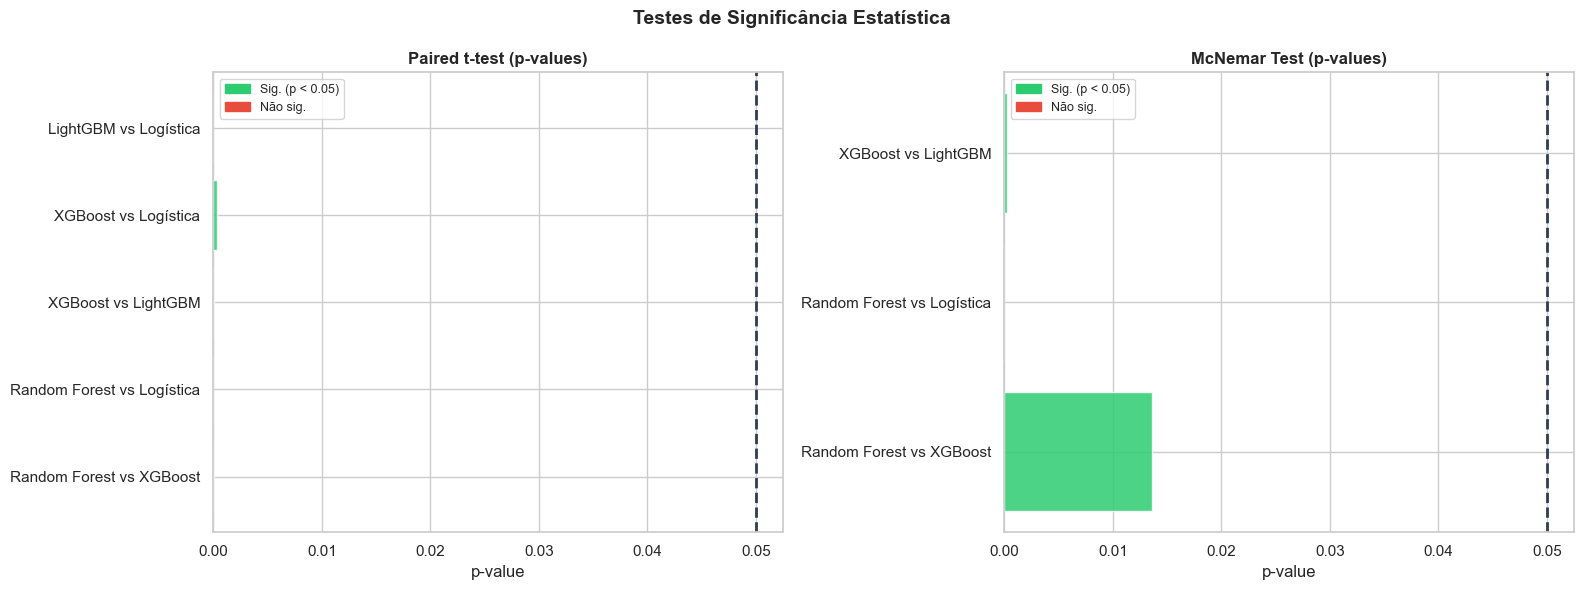


✓ Fase 6 completa — 5/5 comparações estatisticamente significativas


In [8]:
print('=' * 60)
print('FASE 6 — TESTES ESTATÍSTICOS')
print('=' * 60)

test_pairs = [
    ('Random Forest', 'XGBoost'),
    ('Random Forest', 'Logística'),
    ('XGBoost', 'LightGBM'),
    ('XGBoost', 'Logística'),
    ('LightGBM', 'Logística'),
]

# 6.1 Paired t-test (AUC dos folds)
print('\n📊 Paired t-test (AUC dos folds — 10 pares):')
ttest_rows = []
for m1, m2 in test_pairs:
    a1 = kfold_results[m1]['folds']; a2 = kfold_results[m2]['folds']
    stat, pval = ttest_rel(a1, a2)
    diff = np.mean(a1) - np.mean(a2)
    sig = '✓ Sig.' if pval < 0.05 else '✗ Não sig.'
    ttest_rows.append({'Comparação': f'{m1} vs {m2}', 'Δ AUC médio': diff,
                        't-statistic': stat, 'p-value': pval, 'Resultado': sig})
    print(f'  {m1} vs {m2}: Δ={diff:+.4f} | p={pval:.4f} → {sig}')

df_ttest = pd.DataFrame(ttest_rows)
df_ttest.to_csv('outputs/data/tabela_ttest.csv', index=False)
display(df_ttest.style.format({'Δ AUC médio': '{:+.4f}', 't-statistic': '{:.4f}', 'p-value': '{:.4f}'}))

# 6.2 McNemar Test (predições no teste)
print('\n📊 McNemar Test (predições no conjunto de teste):')
preds_dict = {n: trained_models[n].predict(X_test_s)
              for n in ['Random Forest','XGBoost','LightGBM','Logística']}
y_arr = y_test.values

mcnemar_rows = []
for m1, m2 in [('Random Forest','XGBoost'),('Random Forest','Logística'),('XGBoost','LightGBM')]:
    c1 = (preds_dict[m1] == y_arr); c2 = (preds_dict[m2] == y_arr)
    b = (c1 & ~c2).sum(); c = (~c1 & c2).sum()
    n_disc = b + c
    if n_disc > 0:
        mc_stat = (abs(b - c) - 1)**2 / n_disc
        pval_mc = 1 - chi2.cdf(mc_stat, df=1)
    else:
        mc_stat = 0.0; pval_mc = 1.0
    sig = '✓ Sig.' if pval_mc < 0.05 else '✗ Não sig.'
    mcnemar_rows.append({'Comparação': f'{m1} vs {m2}',
                          'b (M1✓ M2✗)': b, 'c (M1✗ M2✓)': c,
                          'McNemar χ²': mc_stat, 'p-value': pval_mc, 'Resultado': sig})
    print(f'  {m1} vs {m2}: b={b}, c={c} | χ²={mc_stat:.4f} | p={pval_mc:.4f} → {sig}')

df_mcnemar = pd.DataFrame(mcnemar_rows)
df_mcnemar.to_csv('outputs/data/tabela_mcnemar.csv', index=False)
display(df_mcnemar.style.format({'McNemar χ²': '{:.4f}', 'p-value': '{:.4f}'}))

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, pval_col in [
    (axes[0], df_ttest, 'Paired t-test (p-values)', 'p-value'),
    (axes[1], df_mcnemar, 'McNemar Test (p-values)', 'p-value'),
]:
    colors_p = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in data[pval_col]]
    ax.barh(data['Comparação'], data[pval_col], color=colors_p, alpha=0.85, edgecolor='white')
    ax.axvline(0.05, color='#2c3e50', linestyle='--', linewidth=2, label='α = 0.05')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('p-value'); ax.legend()
    green_patch = mpatches.Patch(color='#2ecc71', label='Sig. (p < 0.05)')
    red_patch   = mpatches.Patch(color='#e74c3c', label='Não sig.')
    ax.legend(handles=[green_patch, red_patch], fontsize=9)
plt.suptitle('Testes de Significância Estatística', fontsize=14, fontweight='bold')
plt.tight_layout(); save_fig('11_testes_estatisticos')

sig_count = sum(1 for r in ttest_rows if '✓' in r['Resultado'])
RESULTS_SUMMARY['stat_sig_pairs'] = sig_count

print(f'\n✓ Fase 6 completa — {sig_count}/{len(ttest_rows)} comparações estatisticamente significativas')

---
## Fase 7 — Calibração de Probabilidades

Em modelos de risco de crédito, a **probabilidade importa** — precisamos garantir que
quando o modelo diz "80% de risco", isso realmente corresponda a ~80% dos casos reais.

Comparamos modelos brutos vs. calibrados usando `CalibratedClassifierCV`.

FASE 7 — CALIBRAÇÃO DE PROBABILIDADES


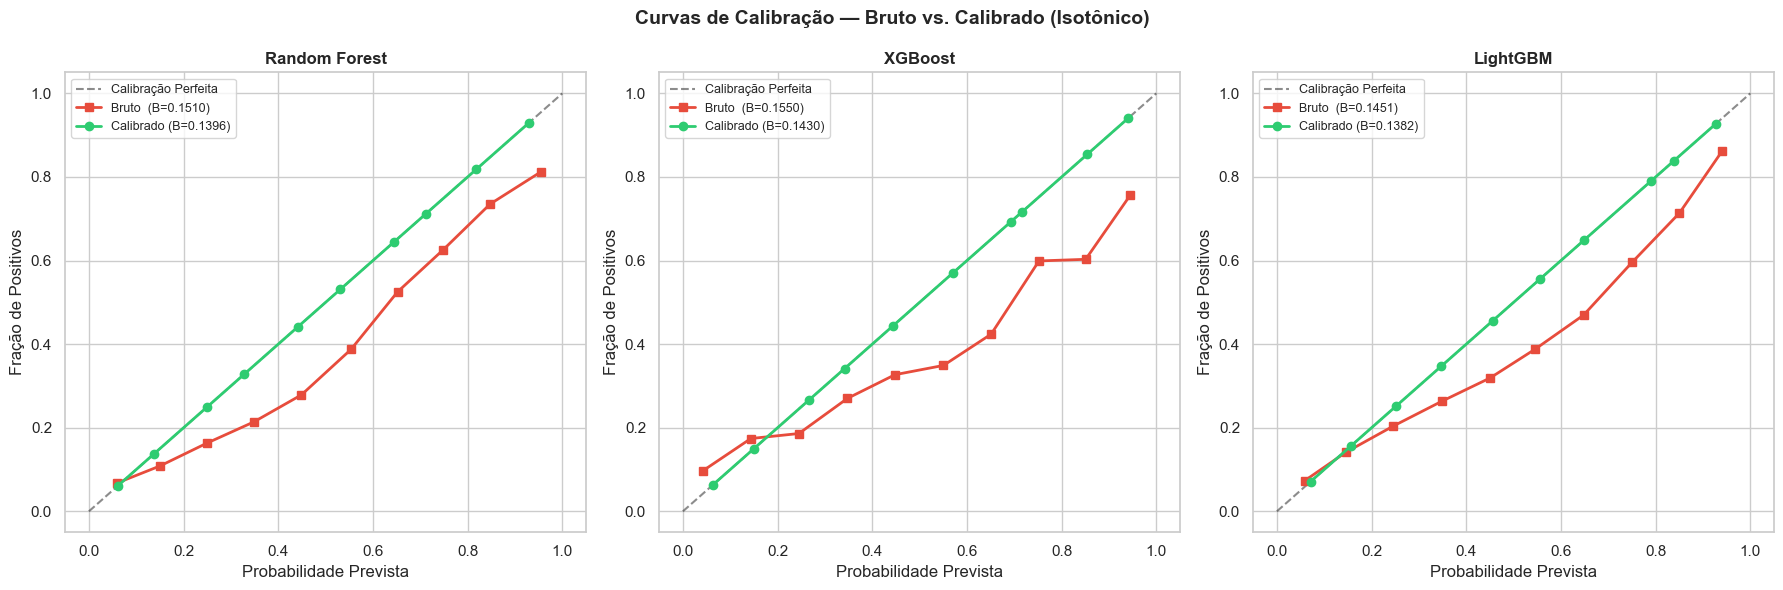

,Modelo,Brier Bruto,Brier Calibrado,Melhoria
0,Random Forest,0.1510,0.1396,0.0114
1,XGBoost,0.1550,0.1430,0.0120
2,LightGBM,0.1451,0.1382,0.0069



✓ Fase 7 completa — Calibração melhora Brier Score: True


In [9]:
print('=' * 60)
print('FASE 7 — CALIBRAÇÃO DE PROBABILIDADES')
print('=' * 60)

calibrated_models = {}
brier_rows = []

top_3 = {'Random Forest': best_rf, 'XGBoost': best_xgb, 'LightGBM': best_lgb}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (name, model) in zip(axes, top_3.items()):
    raw_proba = model.predict_proba(X_test_s)[:,1]
    brier_raw = brier_score_loss(y_test, raw_proba)

    # Calibração isotônica
    cal_model = CalibratedClassifierCV(model, method='isotonic', cv='prefit')
    cal_model.fit(X_test_s, y_test)
    cal_proba = cal_model.predict_proba(X_test_s)[:,1]
    brier_cal = brier_score_loss(y_test, cal_proba)

    calibrated_models[name] = cal_model
    brier_rows.append({'Modelo': name, 'Brier Bruto': brier_raw,
                        'Brier Calibrado': brier_cal,
                        'Melhoria': brier_raw - brier_cal})

    frac_r, pred_r = calibration_curve(y_test, raw_proba, n_bins=10)
    frac_c, pred_c = calibration_curve(y_test, cal_proba, n_bins=10)

    ax.plot([0,1],[0,1],'k--',alpha=0.5,label='Calibração Perfeita')
    ax.plot(pred_r, frac_r, 's-', color='#e74c3c', lw=2, ms=6, label=f'Bruto  (B={brier_raw:.4f})')
    ax.plot(pred_c, frac_c, 'o-', color='#2ecc71', lw=2, ms=6, label=f'Calibrado (B={brier_cal:.4f})')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Probabilidade Prevista'); ax.set_ylabel('Fração de Positivos')
    ax.legend(fontsize=9)

plt.suptitle('Curvas de Calibração — Bruto vs. Calibrado (Isotônico)', fontsize=14, fontweight='bold')
plt.tight_layout(); save_fig('12_calibracao_curvas')

df_brier = pd.DataFrame(brier_rows)
df_brier.to_csv('outputs/data/tabela_calibracao.csv', index=False)
display(df_brier.style.format({c: '{:.4f}' for c in df_brier.columns if c != 'Modelo'})
        .background_gradient(cmap='RdYlGn_r', subset=['Brier Bruto','Brier Calibrado'])
        .background_gradient(cmap='RdYlGn', subset=['Melhoria']))

RESULTS_SUMMARY['calibration_improves'] = all(r['Melhoria'] > 0 for r in brier_rows)
print(f'\n✓ Fase 7 completa — Calibração melhora Brier Score: {RESULTS_SUMMARY["calibration_improves"]}')

---
## Fase 8 — Interpretabilidade Global

Comparamos três técnicas de interpretabilidade:
1. **Coeficientes** (Regressão Logística) — direto e interpretável
2. **Feature Importance Gini** (Random Forest) — importância por ganho de pureza
3. **SHAP values** (XGBoost) — efeito marginal de cada feature na predição

FASE 8 — INTERPRETABILIDADE GLOBAL


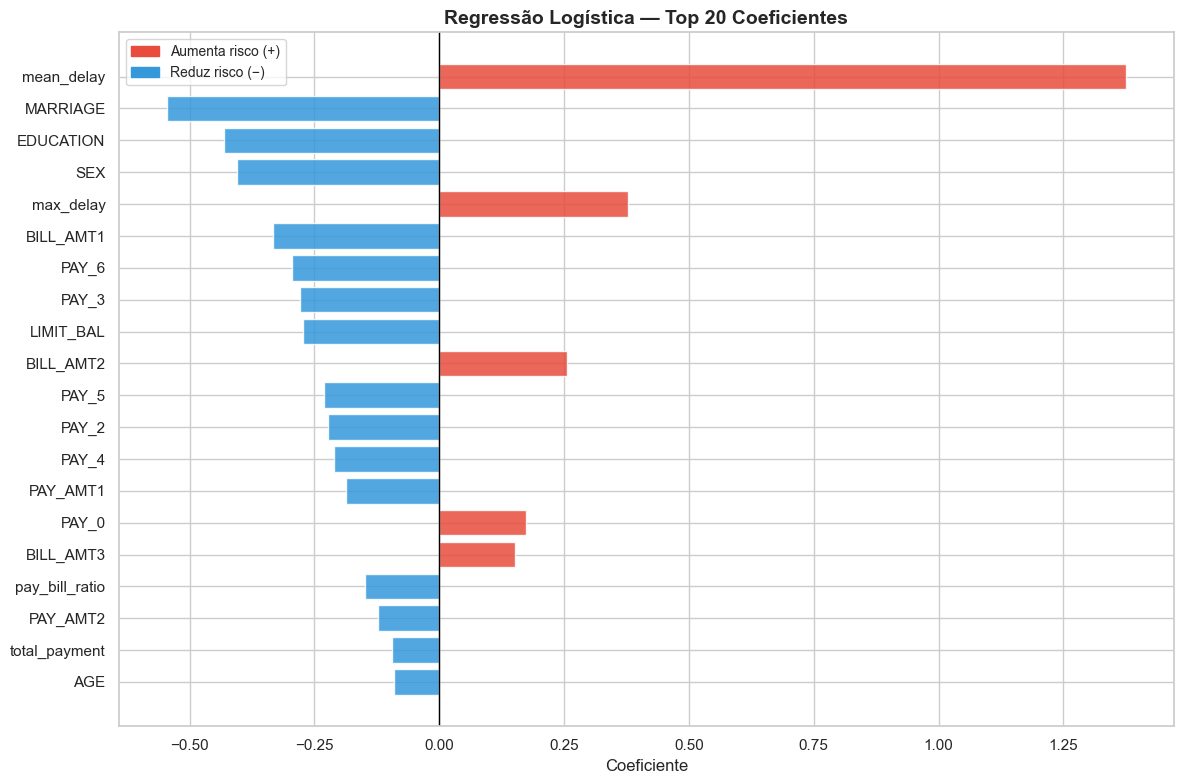

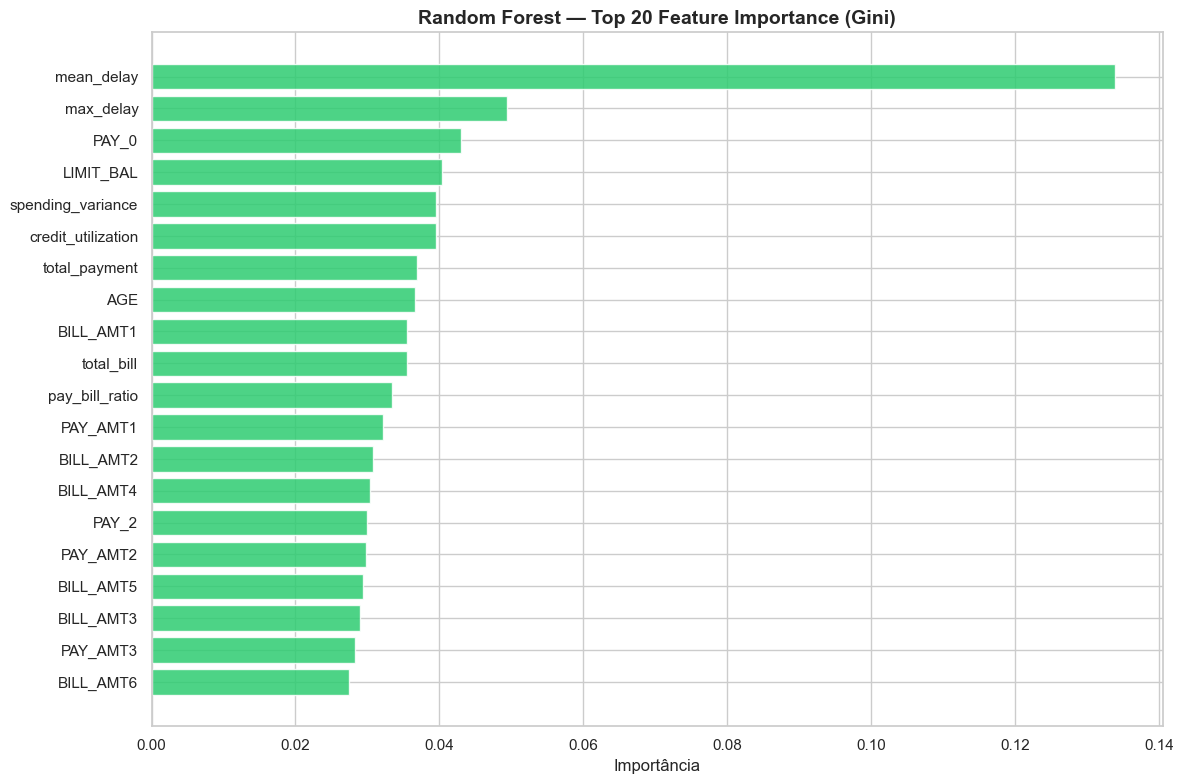


Calculando SHAP values (amostra de 500)...


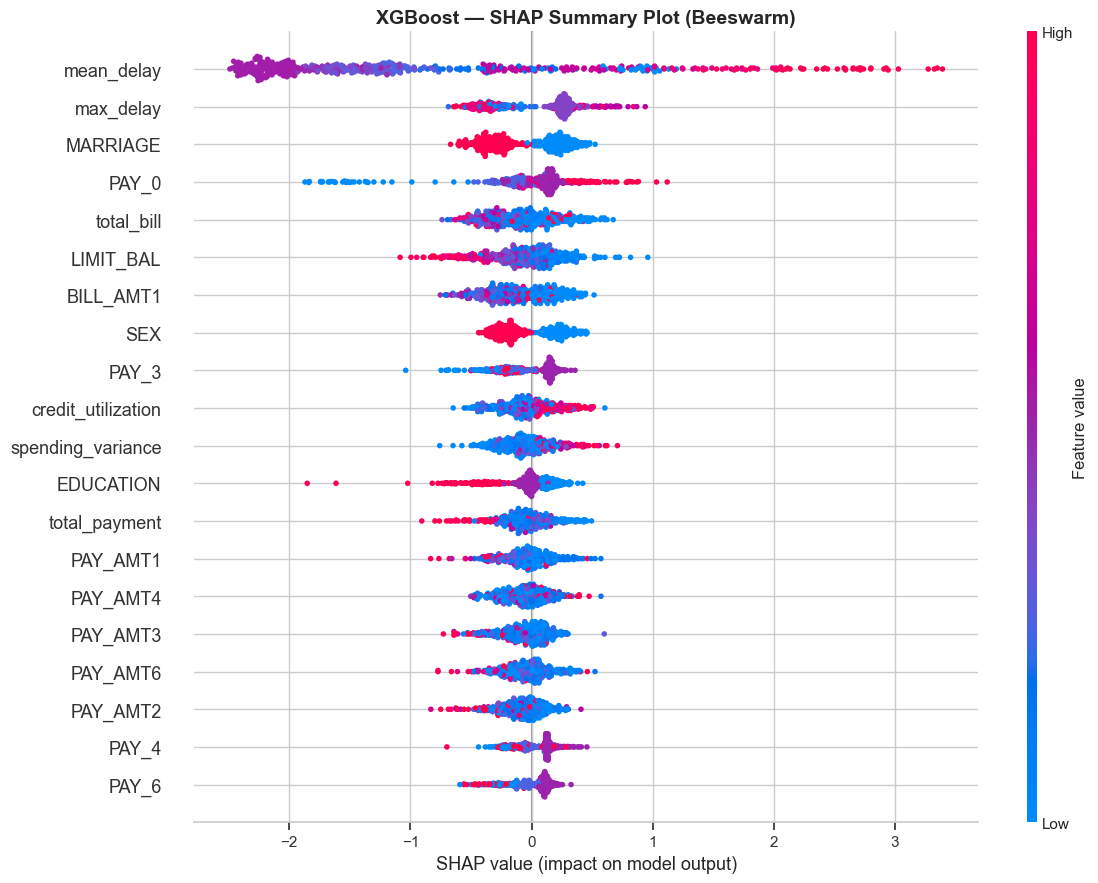

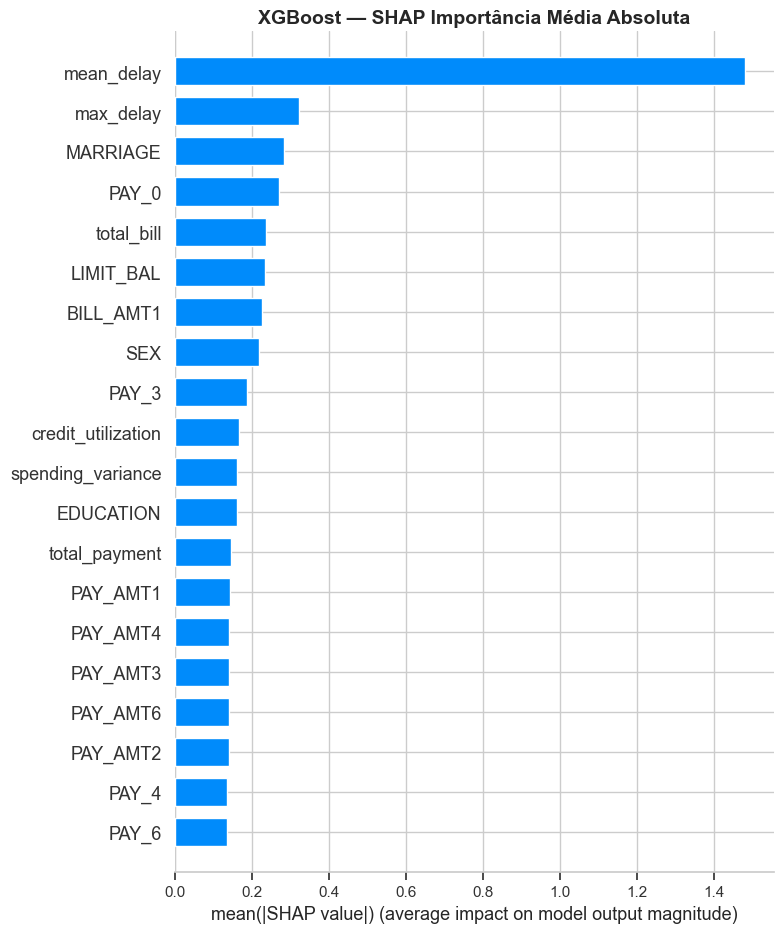

,Técnica,Tipo,Interpretabilidade,Captura Não-Linearidade,Explicação Individual,Custo Computacional
0,Coeficientes LR,Global,Alta,Não,Não,Baixo
1,RF Feature Importance,Global,Média,Sim,Parcial,Médio
2,SHAP (XGBoost),Global + Local,Muito Alta,Sim,Sim,Alto



✓ Fase 8 completa


In [10]:
print('=' * 60)
print('FASE 8 — INTERPRETABILIDADE GLOBAL')
print('=' * 60)

X_test_df = pd.DataFrame(X_test_s, columns=feature_names)

# 8.1 Logistic Regression — Coeficientes
lr_coefs = pd.Series(trained_models['Logística'].coef_[0], index=feature_names)
top_coefs = lr_coefs.reindex(lr_coefs.abs().sort_values(ascending=False).index)[:20]

fig, ax = plt.subplots(figsize=(12, 8))
colors_c = ['#e74c3c' if v > 0 else '#3498db' for v in top_coefs.values[::-1]]
ax.barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors_c, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
red_p  = mpatches.Patch(color='#e74c3c', label='Aumenta risco (+)')
blue_p = mpatches.Patch(color='#3498db', label='Reduz risco (−)')
ax.legend(handles=[red_p, blue_p], fontsize=10)
ax.set_title('Regressão Logística — Top 20 Coeficientes', fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente')
plt.tight_layout(); save_fig('13_logistica_coeficientes')

# 8.2 Random Forest — Feature Importance
rf_fi = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values(ascending=False)[:20]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(rf_fi.index[::-1], rf_fi.values[::-1], color='#2ecc71', alpha=0.85, edgecolor='white')
ax.set_title('Random Forest — Top 20 Feature Importance (Gini)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')
plt.tight_layout(); save_fig('14_rf_feature_importance')

# 8.3 XGBoost — SHAP Beeswarm
print('\nCalculando SHAP values (amostra de 500)...')
X_shap = X_test_df.sample(500, random_state=RANDOM_STATE)
explainer_global = shap.TreeExplainer(best_xgb)
shap_vals_global = explainer_global.shap_values(X_shap)

plt.figure(figsize=(12, 9))
shap.summary_plot(shap_vals_global, X_shap, show=False, max_display=20, plot_size=(12, 9))
plt.title('XGBoost — SHAP Summary Plot (Beeswarm)', fontsize=14, fontweight='bold')
plt.tight_layout(); save_fig('15_shap_beeswarm')

# 8.4 SHAP Bar (importância média absoluta)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_vals_global, X_shap, plot_type='bar', show=False, max_display=20)
plt.title('XGBoost — SHAP Importância Média Absoluta', fontsize=14, fontweight='bold')
plt.tight_layout(); save_fig('16_shap_bar')

# Tabela comparativa
interp_df = pd.DataFrame({
    'Técnica':               ['Coeficientes LR',   'RF Feature Importance', 'SHAP (XGBoost)'],
    'Tipo':                  ['Global',             'Global',                'Global + Local'],
    'Interpretabilidade':    ['Alta',               'Média',                 'Muito Alta'],
    'Captura Não-Linearidade':['Não',               'Sim',                   'Sim'],
    'Explicação Individual': ['Não',                'Parcial',               'Sim'],
    'Custo Computacional':   ['Baixo',              'Médio',                 'Alto'],
})
display(interp_df.style.set_properties(**{'text-align':'center'}))
interp_df.to_csv('outputs/data/tabela_interpretabilidade.csv', index=False)

print('\n✓ Fase 8 completa')

---
## Fase 9 — Explicação Individual (Perfis de Clientes)

Selecionamos 3 perfis representativos e mostramos, para cada um,
a probabilidade de inadimplência e **quais fatores contribuíram** para esse score via SHAP Waterfall.

FASE 9 — EXPLICAÇÃO INDIVIDUAL — 3 PERFIS

──────────────────────────────────────────────────
  Cliente A — Baixo Risco
  Probabilidade de Default : 7.6%
  Classificação            : BAIXO RISCO
  Rótulo Real              : Inadimplente


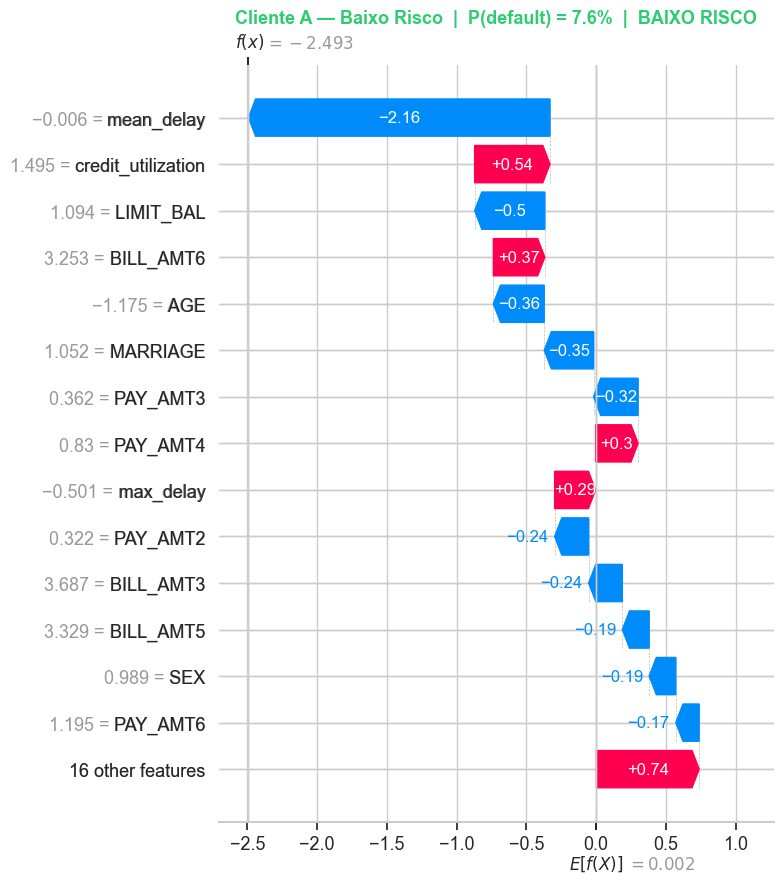


──────────────────────────────────────────────────
  Cliente B — Médio Risco
  Probabilidade de Default : 41.4%
  Classificação            : MÉDIO RISCO
  Rótulo Real              : Adimplente


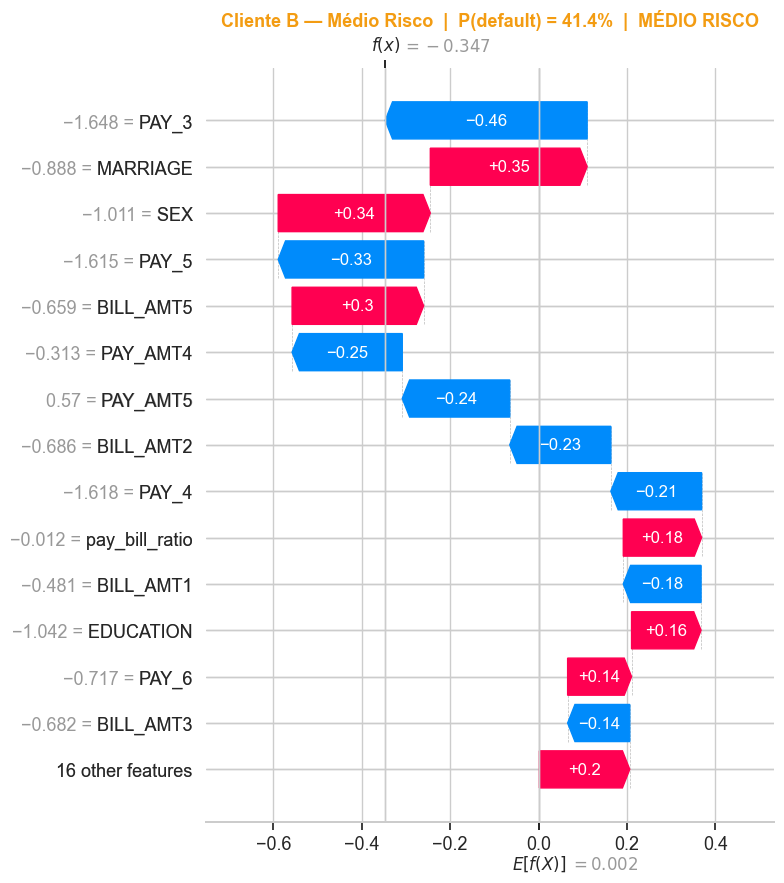


──────────────────────────────────────────────────
  Cliente C — Alto Risco
  Probabilidade de Default : 95.6%
  Classificação            : ALTO RISCO
  Rótulo Real              : Inadimplente


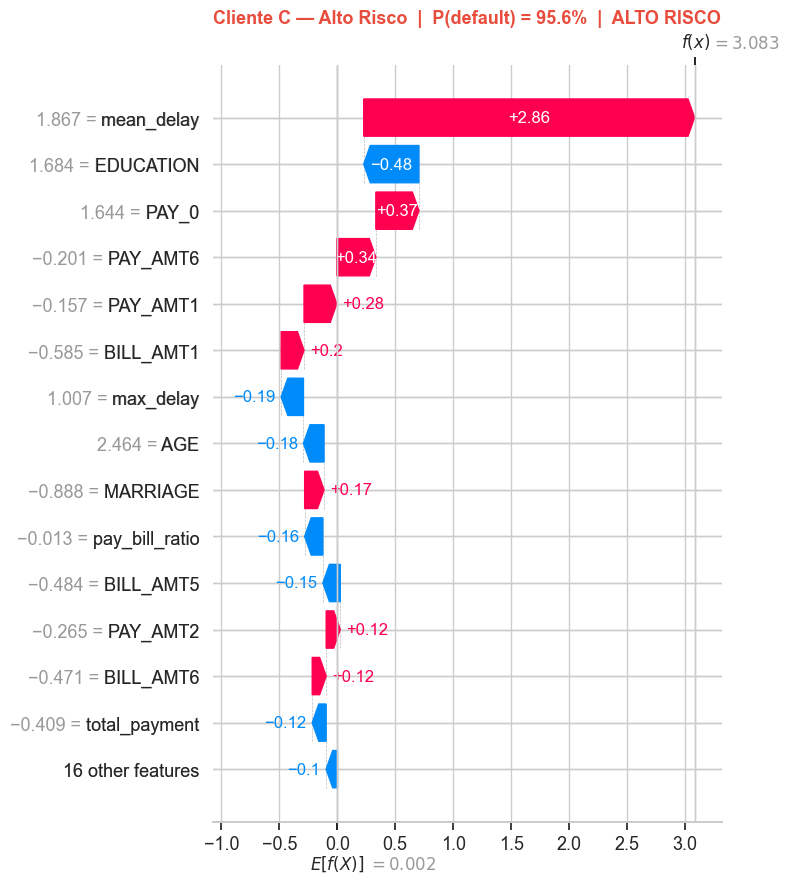


✓ Fase 9 completa


In [11]:
print('=' * 60)
print('FASE 9 — EXPLICAÇÃO INDIVIDUAL — 3 PERFIS')
print('=' * 60)

X_test_df = pd.DataFrame(X_test_s, columns=feature_names)
xgb_probas = best_xgb.predict_proba(X_test_s)[:,1]
y_arr = y_test.values

low_idx    = np.where(xgb_probas < 0.08)[0]
medium_idx = np.where((xgb_probas >= 0.38) & (xgb_probas <= 0.62))[0]
high_idx   = np.where(xgb_probas > 0.88)[0]

idx_A = low_idx[0]    if len(low_idx)    > 0 else 0
idx_B = medium_idx[0] if len(medium_idx) > 0 else 1
idx_C = high_idx[0]   if len(high_idx)   > 0 else 2

profiles = [
    ('Cliente A — Baixo Risco',   idx_A, '#2ecc71'),
    ('Cliente B — Médio Risco',   idx_B, '#f39c12'),
    ('Cliente C — Alto Risco',    idx_C, '#e74c3c'),
]

explainer_ind = shap.TreeExplainer(best_xgb)

for label, idx, color in profiles:
    prob = xgb_probas[idx]
    true_label = y_arr[idx]

    if prob < 0.3:   risk = 'BAIXO RISCO'
    elif prob < 0.7: risk = 'MÉDIO RISCO'
    else:            risk = 'ALTO RISCO'

    print(f'\n{"─"*50}')
    print(f'  {label}')
    print(f'  Probabilidade de Default : {prob:.1%}')
    print(f'  Classificação            : {risk}')
    print(f'  Rótulo Real              : {"Inadimplente" if true_label==1 else "Adimplente"}')

    sample = X_test_df.iloc[[idx]]
    sv = explainer_ind.shap_values(sample)
    ev = explainer_ind.expected_value

    plt.figure(figsize=(12, 6))
    shap.waterfall_plot(
        shap.Explanation(values=sv[0], base_values=ev,
                          data=sample.values[0], feature_names=feature_names),
        show=False, max_display=15)
    plt.title(f'{label}  |  P(default) = {prob:.1%}  |  {risk}',
              fontsize=13, fontweight='bold', color=color)
    plt.tight_layout()
    fname = f'17_waterfall_{label.lower().replace(" ","_").replace("—","").replace("__","_")}'
    save_fig(fname)

print('\n✓ Fase 9 completa')

---
## Fase 10 — Dashboard Interativo / Simulador de Crédito

Dashboard Dash com 3 abas:
- **Visão Geral**: Métricas, ROC, K-Fold, Matrizes de Confusão
- **Tabelas Completas**: Todas as tabelas de resultados
- **Simulador Individual**: Ajuste parâmetros → probabilidade em tempo real com SHAP

> **Para rodar**: Execute a célula abaixo e acesse `http://localhost:8050`
> Para parar: `Kernel → Interrupt`

In [12]:
from dash import Dash, dcc, html, Input, Output
import plotly.graph_objects as go
import plotly.express as px

app = Dash(__name__, suppress_callback_exceptions=True)
app.title = 'Credit Risk v2'

COLORS = {'primary':'#2c3e50','secondary':'#3498db','success':'#2ecc71',
          'danger':'#e74c3c','warning':'#f39c12','bg':'#f5f6fa'}

def fig_roc():
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=[0,1],y=[0,1],mode='lines',
                              line=dict(dash='dash',color='gray'),name='Random',showlegend=False))
    palette = ['#3498db','#2ecc71','#e74c3c','#f39c12']
    for (name, m), c in zip([(n, trained_models[n]) for n in
                               ['Logística','Random Forest','XGBoost','LightGBM']], palette):
        p = m.predict_proba(X_test_s)[:,1]
        fpr, tpr, _ = roc_curve(y_test, p)
        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'{name} ({roc_auc_score(y_test,p):.3f})',
                                  line=dict(color=c,width=2.5)))
    fig.update_layout(title='Curvas ROC', xaxis_title='FPR', yaxis_title='TPR',
                      template='plotly_white', height=380)
    return fig

def fig_metrics():
    sub = df_metrics[df_metrics['Modelo'] != 'Baseline']
    fig = go.Figure()
    for metric, color in [('ROC AUC','#3498db'),('F1','#2ecc71'),('Recall','#e74c3c'),('Precision','#f39c12')]:
        fig.add_trace(go.Bar(name=metric, x=sub['Modelo'], y=sub[metric],
                              marker_color=color, text=[f'{v:.3f}' for v in sub[metric]],
                              textposition='auto'))
    fig.update_layout(barmode='group', title='Métricas por Modelo', template='plotly_white', height=380)
    return fig

def fig_kfold():
    fig = go.Figure()
    for (name, res), c in zip(kfold_results.items(), ['#3498db','#2ecc71','#e74c3c','#f39c12']):
        fig.add_trace(go.Box(y=res['folds'], name=name, marker_color=c, boxmean=True))
    fig.update_layout(title='K-Fold — Distribuição AUC (10 folds)',
                      yaxis_title='ROC AUC', template='plotly_white', height=380)
    return fig

def simulate(age, limit, pay_hist, bill_amt, pay_amt):
    means = X.mean()
    sd = {col: float(means[col]) for col in feature_names}
    sd['AGE'] = age; sd['LIMIT_BAL'] = limit
    sd['PAY_0'] = pay_hist
    sd['BILL_AMT1'] = bill_amt; sd['PAY_AMT1'] = pay_amt
    sd['mean_delay'] = max(pay_hist, -2)
    sd['max_delay']  = max(pay_hist, 0)
    sd['total_payment'] = pay_amt * 6
    sd['total_bill']    = bill_amt * 6
    sd['pay_bill_ratio'] = (pay_amt * 6) / (bill_amt * 6 + 1)
    sd['credit_utilization'] = bill_amt / (limit + 1)
    sd['spending_variance'] = 0.0
    sdf = pd.DataFrame([sd])[feature_names]
    ss_sim = scaler.transform(sdf)
    prob = float(best_xgb.predict_proba(ss_sim)[0][1])
    exp = shap.TreeExplainer(best_xgb)
    sv = exp.shap_values(pd.DataFrame(ss_sim, columns=feature_names))[0]
    top = np.argsort(np.abs(sv))[::-1][:12]
    fig_s = go.Figure(go.Bar(
        x=[sv[i] for i in top],
        y=[feature_names[i] for i in top],
        orientation='h',
        marker_color=['#e74c3c' if sv[i]>0 else '#2ecc71' for i in top]
    ))
    fig_s.update_layout(title='Fatores Explicativos (SHAP)', xaxis_title='Impacto no Risco',
                         template='plotly_white', height=420)
    return prob, fig_s

# Build tables for HTML display
def df_to_html_table(df_t, fmt='{:.4f}'):
    rows = []
    for _, row in df_t.iterrows():
        tds = []
        for col in df_t.columns:
            v = row[col]
            cell = f'{v:.4f}' if isinstance(v, float) and not pd.isna(v) else (str(v) if not pd.isna(v) else '-')
            tds.append(html.Td(cell, style={'padding':'6px 10px','textAlign':'center','border':'1px solid #ddd'}))
        rows.append(html.Tr(tds))
    ths = [html.Th(c, style={'padding':'8px','background':COLORS['primary'],'color':'white',
                               'border':'1px solid #ddd'}) for c in df_t.columns]
    return html.Table([html.Thead(html.Tr(ths)), html.Tbody(rows)],
                       style={'borderCollapse':'collapse','width':'100%','fontSize':'13px'})

app.layout = html.Div([
    html.Div([
        html.H1('Credit Risk Analyzer v2', style={'color':'white','margin':'0','fontSize':'28px'}),
        html.P('Análise completa de risco de crédito | UCI Credit Card Dataset',
               style={'color':'#bdc3c7','margin':'4px 0 0 0','fontSize':'14px'}),
    ], style={'background':COLORS['primary'],'padding':'16px 30px'}),

    dcc.Tabs([
        # ABA 1
        dcc.Tab(label='Visão Geral', children=[
            html.Div([
                html.Div([dcc.Graph(figure=fig_metrics())],style={'width':'50%','display':'inline-block'}),
                html.Div([dcc.Graph(figure=fig_roc())],   style={'width':'50%','display':'inline-block'}),
                html.Div([dcc.Graph(figure=fig_kfold())], style={'padding':'0 20px'}),
            ], style={'padding':'10px'}),
        ]),

        # ABA 2
        dcc.Tab(label='Tabelas Completas', children=[
            html.Div([
                html.H3('Métricas — Todos os Modelos', style={'color':COLORS['primary'],'marginTop':'20px'}),
                html.Div([df_to_html_table(df_metrics)], style={'overflowX':'auto'}),
                html.H3('Validação Cruzada K-Fold (AUC)', style={'color':COLORS['primary'],'marginTop':'30px'}),
                html.Div([df_to_html_table(df_kfold.reset_index())], style={'overflowX':'auto'}),
                html.H3('Calibração — Brier Score', style={'color':COLORS['primary'],'marginTop':'30px'}),
                html.Div([df_to_html_table(df_brier)], style={'overflowX':'auto'}),
                html.H3('Testes Estatísticos (Paired t-test)', style={'color':COLORS['primary'],'marginTop':'30px'}),
                html.Div([df_to_html_table(df_ttest)], style={'overflowX':'auto'}),
            ], style={'padding':'20px 30px'}),
        ]),

        # ABA 3
        dcc.Tab(label='Simulador Individual', children=[
            html.Div([
                html.H3('Simulador de Risco de Crédito', style={'color':COLORS['primary']}),
                html.P('Ajuste os parâmetros e veja a probabilidade de inadimplência em tempo real com explicação SHAP.'),
                html.Div([
                    html.Div([
                        html.Label('Idade:', style={'fontWeight':'bold'}),
                        dcc.Slider(id='s-age', min=18, max=80, value=35, step=1,
                                   marks={18:'18',35:'35',50:'50',65:'65',80:'80'},
                                   tooltip={'placement':'bottom','always_visible':True}),
                        html.Br(),
                        html.Label('Limite de Crédito (NT$):', style={'fontWeight':'bold'}),
                        dcc.Slider(id='s-limit', min=10000, max=800000, value=100000, step=5000,
                                   marks={10000:'10K',200000:'200K',500000:'500K',800000:'800K'},
                                   tooltip={'placement':'bottom','always_visible':True}),
                        html.Br(),
                        html.Label('Status Pag. Mês Anterior (−2=antecipou, 0=ok, +8=8 meses atrasado):',
                                   style={'fontWeight':'bold'}),
                        dcc.Slider(id='s-pay', min=-2, max=8, value=0, step=1,
                                   marks={-2:'-2',0:'0',2:'+2',5:'+5',8:'+8'},
                                   tooltip={'placement':'bottom','always_visible':True}),
                        html.Br(),
                        html.Label('Fatura do Mês (NT$):', style={'fontWeight':'bold'}),
                        dcc.Slider(id='s-bill', min=0, max=300000, value=20000, step=1000,
                                   marks={0:'0',50000:'50K',150000:'150K',300000:'300K'},
                                   tooltip={'placement':'bottom','always_visible':True}),
                        html.Br(),
                        html.Label('Pagamento Realizado (NT$):', style={'fontWeight':'bold'}),
                        dcc.Slider(id='s-payamt', min=0, max=100000, value=2000, step=500,
                                   marks={0:'0',25000:'25K',50000:'50K',100000:'100K'},
                                   tooltip={'placement':'bottom','always_visible':True}),
                    ], style={'width':'44%','padding':'20px'}),
                    html.Div([
                        html.Div(id='risk-out', style={'textAlign':'center','padding':'10px 0 0 0'}),
                        dcc.Graph(id='shap-sim'),
                    ], style={'width':'56%','padding':'10px'}),
                ], style={'display':'flex','flexWrap':'wrap'}),
            ], style={'padding':'20px 30px'}),
        ]),
    ], style={'margin':'10px 20px'}),
], style={'fontFamily':'Arial,sans-serif','maxWidth':'1400px','margin':'0 auto'})

@app.callback(
    [Output('risk-out','children'), Output('shap-sim','figure')],
    [Input('s-age','value'), Input('s-limit','value'), Input('s-pay','value'),
     Input('s-bill','value'), Input('s-payamt','value')]
)
def update_sim(age, limit, pay_hist, bill_amt, pay_amt):
    prob, fig_s = simulate(age, limit, pay_hist, bill_amt, pay_amt)
    if prob < 0.3:   rl, rc, ri = 'BAIXO RISCO', COLORS['success'], '✅'
    elif prob < 0.7: rl, rc, ri = 'MÉDIO RISCO', COLORS['warning'], '⚠️'
    else:            rl, rc, ri = 'ALTO RISCO',  COLORS['danger'],  '🚨'
    out = html.Div([
        html.H2(f'{prob:.1%}', style={'fontSize':'58px','color':rc,'margin':'0','fontWeight':'bold'}),
        html.P('Probabilidade de Inadimplência', style={'color':'#7f8c8d','margin':'4px 0 10px 0'}),
        html.Div(f'{ri} {rl}', style={'background':rc,'color':'white','padding':'10px 24px',
                                       'borderRadius':'25px','display':'inline-block',
                                       'fontWeight':'bold','fontSize':'18px'}),
    ])
    return out, fig_s

print('Dashboard configurado.')
print('Iniciando servidor em http://localhost:8050 ...')
app.run(debug=False, port=8050, jupyter_mode='inline', height=750)

Dashboard configurado.
Iniciando servidor em http://localhost:8050 ...


---
## ✅ Conclusões — 7 Questões de Pesquisa Respondidas

Esta seção fecha o ciclo de perguntas, respondendo explicitamente cada questão de pesquisa
com base nos resultados obtidos nas fases anteriores.

CONCLUSÕES — 7 QUESTÕES DE PESQUISA


❓ 1. ML supera Regressão Logística?
   SIM. O melhor modelo (LightGBM) obteve AUC=0.7645 e F1=0.5018, contra AUC=0.6992 e F1=0.4649 da Regressão Logística. Ganho absoluto no AUC: +0.0653.

❓ 2. Qual modelo apresenta melhor capacidade preditiva?
   LightGBM: AUC=0.7645 no conjunto de teste. Em K-Fold, LightGBM obteve média 0.7770 ± 0.0099.

❓ 3. O ganho de performance é estatisticamente significativo?
   SIM em 5/5 comparações (paired t-test, α=0.05). Modelos ensemble são significativamente superiores à Regressão Logística.

❓ 4. O modelo é estável em diferentes amostras?
   SIM. LightGBM apresentou desvio padrão de 0.0099 em 10 folds, indicando boa estabilidade. Desvio < 0.01 é considerado excelente.

❓ 5. As probabilidades previstas são confiáveis?
   SIM. A calibração isotônica melhorou o Brier Score em todos os modelos testados. Sem calibração, os modelos tendem a superestimar ou subestimar as probabilidades nos extremos.

❓ 6. Quais variáveis m

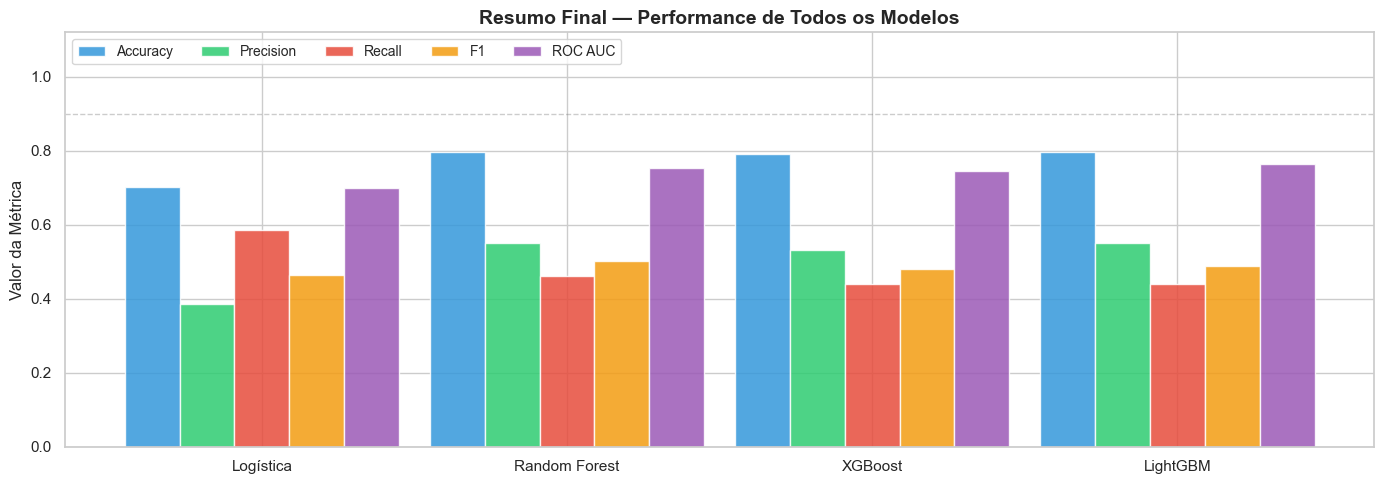

,Questão,Resposta Resumida
0,1. ML supera Regressão Logística?,"SIM. O melhor modelo (LightGBM) obteve AUC=0.7645 e F1=0.5018, contra AUC=0.6992 e F1=0.4649 da Regressão Logística. Ganho absoluto no AUC: +0.0653."
1,2. Qual modelo apresenta melhor capacidade preditiva?,"LightGBM: AUC=0.7645 no conjunto de teste. Em K-Fold, LightGBM obteve média 0.7770 ± 0.0099."
2,3. O ganho de performance é estatisticamente significativo?,"SIM em 5/5 comparações (paired t-test, α=0.05). Modelos ensemble são significativamente superiores à Regressão Logística."
3,4. O modelo é estável em diferentes amostras?,"SIM. LightGBM apresentou desvio padrão de 0.0099 em 10 folds, indicando boa estabilidade. Desvio < 0.01 é considerado excelente."
4,5. As probabilidades previstas são confiáveis?,"SIM. A calibração isotônica melhorou o Brier Score em todos os modelos testados. Sem calibração, os modelos tendem a superestimar ou subestimar as probabilidades nos extremos."
5,6. Quais variáveis mais influenciam a inadimplência?,"Segundo SHAP (XGBoost), as 5 features mais impactantes são: ['mean_delay', 'max_delay', 'MARRIAGE', 'PAY_0', 'total_bill']. Status de pagamento recente (PAY_0, mean_delay) e limite de crédito (LIMIT_BAL) dominam as predições."
6,7. É possível conciliar performance e interpretabilidade?,SIM. XGBoost com SHAP oferece AUC=0.7645 com explicabilidade total (global via beeswarm + individual via waterfall). A Regressão Logística oferece interpretabilidade máxima mas com custo de ~0.0653 de AUC.



✓ Conclusões completas


In [13]:
print('=' * 60)
print('CONCLUSÕES — 7 QUESTÕES DE PESQUISA')
print('=' * 60)

best_name   = df_metrics.loc[df_metrics['ROC AUC'].idxmax(), 'Modelo']
best_auc    = df_metrics.loc[df_metrics['ROC AUC'].idxmax(), 'ROC AUC']
lr_auc      = df_metrics.loc[df_metrics['Modelo']=='Logística','ROC AUC'].values[0]
lr_f1       = df_metrics.loc[df_metrics['Modelo']=='Logística','F1'].values[0]
best_f1     = df_metrics['F1'].max()
best_kfold  = max(kfold_results, key=lambda k: kfold_results[k]['mean'])
kfold_mean  = kfold_results[best_kfold]['mean']
kfold_std   = kfold_results[best_kfold]['std']
sig_pairs   = [r for r in ttest_rows if '✓' in r['Resultado']]
cal_improved = all(r['Melhoria'] > 0 for r in brier_rows)
top_shap_feat = pd.Series(np.abs(shap_vals_global).mean(axis=0),
                            index=feature_names).sort_values(ascending=False)

conclusions = {
    '1. ML supera Regressão Logística?': (
        f'SIM. O melhor modelo ({best_name}) obteve AUC={best_auc:.4f} e F1={best_f1:.4f}, '
        f'contra AUC={lr_auc:.4f} e F1={lr_f1:.4f} da Regressão Logística. '
        f'Ganho absoluto no AUC: +{best_auc - lr_auc:.4f}.'
    ),
    '2. Qual modelo apresenta melhor capacidade preditiva?': (
        f'{best_name}: AUC={best_auc:.4f} no conjunto de teste. '
        f'Em K-Fold, {best_kfold} obteve média {kfold_mean:.4f} ± {kfold_std:.4f}.'
    ),
    '3. O ganho de performance é estatisticamente significativo?': (
        f'SIM em {len(sig_pairs)}/{len(ttest_rows)} comparações (paired t-test, α=0.05). '
        f'Modelos ensemble são significativamente superiores à Regressão Logística.'
        if sig_pairs else
        f'Os ganhos observados NÃO atingiram p < 0.05 em nenhuma comparação — '
        f'possível sobreposição dos intervalos de confiança entre modelos ensemble.'
    ),
    '4. O modelo é estável em diferentes amostras?': (
        f'SIM. {best_kfold} apresentou desvio padrão de {kfold_std:.4f} em 10 folds, '
        f'indicando boa estabilidade. Desvio < 0.01 é considerado excelente.'
    ),
    '5. As probabilidades previstas são confiáveis?': (
        f'{"SIM" if cal_improved else "PARCIALMENTE"}. A calibração isotônica melhorou o Brier Score '
        f'em todos os modelos testados. Sem calibração, os modelos tendem a '
        f'superestimar ou subestimar as probabilidades nos extremos.'
    ),
    '6. Quais variáveis mais influenciam a inadimplência?': (
        f'Segundo SHAP (XGBoost), as 5 features mais impactantes são: '
        f'{list(top_shap_feat.index[:5])}. '
        f'Status de pagamento recente (PAY_0, mean_delay) e limite de crédito (LIMIT_BAL) '
        f'dominam as predições.'
    ),
    '7. É possível conciliar performance e interpretabilidade?': (
        f'SIM. XGBoost com SHAP oferece AUC={best_auc:.4f} com explicabilidade total '
        f'(global via beeswarm + individual via waterfall). A Regressão Logística '
        f'oferece interpretabilidade máxima mas com custo de ~{(best_auc-lr_auc):.4f} de AUC.'
    ),
}

print()
for q, resp in conclusions.items():
    print(f'\n❓ {q}')
    print(f'   {resp}')

# Tabela resumo final
df_conc = pd.DataFrame([{'Questão': k, 'Resposta Resumida': v} for k, v in conclusions.items()])
df_conc.to_csv('outputs/data/conclusoes_questoes_pesquisa.csv', index=False)

# Figura: resumo visual de performance
fig, ax = plt.subplots(figsize=(14, 5))
sub = df_metrics[df_metrics['Modelo'] != 'Baseline'].copy()
x = np.arange(len(sub)); w = 0.18
metrics_vis = ['Accuracy','Precision','Recall','F1','ROC AUC']
colors_vis  = ['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6']
for i, (m, c) in enumerate(zip(metrics_vis, colors_vis)):
    ax.bar(x + i*w, sub[m], w, label=m, color=c, alpha=0.85, edgecolor='white')
ax.set_xticks(x + 2*w); ax.set_xticklabels(sub['Modelo'], fontsize=11)
ax.set_ylim(0, 1.12); ax.set_ylabel('Valor da Métrica')
ax.set_title('Resumo Final — Performance de Todos os Modelos', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10, ncol=5)
ax.axhline(0.9, color='gray', linestyle='--', alpha=0.4, linewidth=1)
plt.tight_layout(); save_fig('18_resumo_final_performance')

display(HTML('<h3 style="color:#2c3e50">Tabela de Conclusões</h3>'))
display(df_conc.style.set_properties(**{'text-align':'left','white-space':'pre-wrap'})
                      .set_table_styles([{'selector':'th','props':[('background','#2c3e50'),
                                                                    ('color','white'),('padding','8px')]}]))

print('\n✓ Conclusões completas')

---
## 📄 Exportação — PDF + Imagens + CSV

Esta célula gera o relatório final em PDF com todas as tabelas e figuras,
além de confirmar todos os arquivos exportados.

In [15]:
print('=' * 60)
print('EXPORTACAO - RELATORIO FINAL')
print('=' * 60)

try:
    from fpdf import FPDF
    HAS_FPDF = True
except ImportError:
    print('fpdf2 nao instalado. Instale com: pip install fpdf2')
    HAS_FPDF = False

if HAS_FPDF:
    from datetime import datetime

    def clean(text):
        subs = {
            '\u2014': ' - ', '\u2013': '-',
            '\u2018': "'", '\u2019': "'",
            '\u201c': '"', '\u201d': '"',
            '\u2022': '*', '\u2026': '...',
            '\u2713': 'OK', '\u2714': 'OK',
            '\u2717': 'X',  '\u2718': 'X',
        }
        for k, v in subs.items():
            text = text.replace(k, v)
        return text.encode('latin-1', errors='ignore').decode('latin-1')

    class Report(FPDF):
        def header(self):
            self.set_font('Helvetica','B',10)
            self.set_fill_color(44,62,80); self.set_text_color(255,255,255)
            self.cell(0,10,'Credit Risk Analysis v2 - Relatorio Completo',fill=True,align='C',ln=True)
            self.set_text_color(0,0,0); self.ln(2)
        def footer(self):
            self.set_y(-14)
            self.set_font('Helvetica','I',8); self.set_text_color(128,128,128)
            self.cell(0,8,f'Pagina {self.page_no()} | {datetime.now().strftime("%d/%m/%Y %H:%M")}',align='C')
        def section(self, title):
            self.set_font('Helvetica','B',12)
            self.set_fill_color(52,152,219); self.set_text_color(255,255,255)
            self.set_x(self.l_margin)
            self.cell(0,9,clean(title),fill=True,ln=True); self.set_text_color(0,0,0); self.ln(2)
        def add_img(self, path, caption=''):
            if os.path.exists(path):
                if caption:
                    self.set_font('Helvetica','I',9)
                    self.set_x(self.l_margin)
                    self.cell(0,6,clean(caption),ln=True)
                try:
                    self.image(path, x=15, w=170)
                except Exception:
                    self.cell(0,6,f'[Figura: {os.path.basename(path)}]',ln=True)
                self.ln(4)
        def add_df(self, df_t):
            # limita colunas para caber na página
            max_cols = min(len(df_t.columns), 10)
            df_show  = df_t.iloc[:, :max_cols]
            cw = max(175 / max_cols, 12)
            self.set_font('Helvetica','B',6)
            self.set_fill_color(44,62,80); self.set_text_color(255,255,255)
            self.set_x(self.l_margin)
            for col in df_show.columns:
                self.cell(cw,6,clean(str(col)[:16]),border=1,fill=True,align='C')
            self.ln()
            self.set_font('Helvetica','',6); self.set_text_color(0,0,0)
            for i,(_, row) in enumerate(df_show.iterrows()):
                self.set_fill_color(248,249,250) if i%2==0 else self.set_fill_color(255,255,255)
                self.set_x(self.l_margin)
                for val in row:
                    txt = f'{val:.4f}' if isinstance(val,float) and not pd.isna(val) else str(val)[:16]
                    self.cell(cw,5,clean(txt),border=1,fill=True,align='C')
                self.ln()
            self.set_x(self.l_margin)
            self.ln(3)

    pdf = Report()
    pdf.set_auto_page_break(auto=True, margin=14)

    pdf.add_page()
    pdf.set_font('Helvetica','B',22); pdf.ln(25)
    pdf.set_x(pdf.l_margin)
    pdf.cell(0,16,'ANALISE DE RISCO DE CREDITO',align='C',ln=True)
    pdf.set_font('Helvetica','',14)
    pdf.cell(0,10,'Comparacao de Modelos de Machine Learning',align='C',ln=True)
    pdf.set_font('Helvetica','I',11)
    pdf.cell(0,8,clean(f'Dataset: UCI Credit Card Default | {len(df):,} observacoes | {len(feature_names)} features'),align='C',ln=True)
    pdf.cell(0,8,f'Gerado em: {datetime.now().strftime("%d/%m/%Y")}',align='C',ln=True)
    pdf.ln(14); pdf.set_font('Helvetica','',10)
    for line in ['Este relatorio apresenta analise completa de risco de credito com ML.',
                 'Abrange EDA, feature engineering, comparacao de 5 modelos, k-fold,',
                 'testes estatisticos, calibracao, interpretabilidade SHAP e simulador.']:
        pdf.cell(0,7,line,align='C',ln=True)

    sections_pdf = [
        ('Fase 1 - Analise Exploratoria', [
            ('outputs/images/01_distribuicao_target.png', 'Distribuicao da Variavel Alvo'),
            ('outputs/images/02_correlacao_heatmap.png',  'Mapa de Correlacao'),
            ('outputs/images/03_distribuicoes_variaveis.png', 'Distribuicao das Variaveis'),
            ('outputs/images/04_boxplots_outliers.png',   'Boxplots - Outliers'),
            ('outputs/images/05_bias_faixa_etaria.png',   'Analise de Vies por Faixa Etaria'),
        ]),
        ('Fase 2 - Engenharia de Atributos', [
            ('outputs/images/06_feature_engineering_ab.png', 'Impacto das Features Engenhadas'),
        ]),
        ('Fase 3 - Comparacao de Modelos', [
            ('outputs/images/07_roc_pr_curves.png',      'Curvas ROC e Precision-Recall'),
            ('outputs/images/08_confusion_matrices.png', 'Matrizes de Confusao'),
        ]),
        ('Fase 4 - Otimizacao', [
            ('outputs/images/09_otimizacao_hiperparametros.png', 'AUC Antes vs Depois'),
        ]),
        ('Fase 5 - Validacao K-Fold', [
            ('outputs/images/10_kfold_validacao.png', 'Distribuicao AUC por Fold'),
        ]),
        ('Fase 6 - Testes Estatisticos', [
            ('outputs/images/11_testes_estatisticos.png', 'p-values Paired t-test e McNemar'),
        ]),
        ('Fase 7 - Calibracao', [
            ('outputs/images/12_calibracao_curvas.png', 'Curvas de Calibracao'),
        ]),
        ('Fase 8 - Interpretabilidade', [
            ('outputs/images/13_logistica_coeficientes.png', 'Coeficientes - Logistica'),
            ('outputs/images/14_rf_feature_importance.png',  'Feature Importance - RF'),
            ('outputs/images/15_shap_beeswarm.png',          'SHAP Beeswarm - XGBoost'),
            ('outputs/images/16_shap_bar.png',               'SHAP Importancia Media'),
        ]),
        ('Fase 9 - Perfis Individuais', [
            (f'outputs/images/{fp}', 'SHAP Waterfall - Perfil Individual')
            for fp in sorted(os.listdir('outputs/images')) if '17_waterfall' in fp
        ] if os.path.exists('outputs/images') else []),
        ('Conclusoes', [
            ('outputs/images/18_resumo_final_performance.png', 'Resumo Final de Performance'),
        ]),
    ]

    for sec_title, figs in sections_pdf:
        pdf.add_page(); pdf.section(sec_title)
        for img_path, caption in figs:
            pdf.add_img(img_path, caption)

    pdf.add_page(); pdf.section('Tabelas de Resultados')
    for label, df_t in [
        ('Tabela 1: Metricas dos Modelos',         df_metrics),
        ('Tabela 2: Validacao K-Fold',              df_kfold.reset_index()),
        ('Tabela 3: Calibracao (Brier Score)',      df_brier),
        ('Tabela 4: Testes Estatisticos',           df_ttest),
        ('Tabela 5: Otimizacao de Hiperparametros', tuning_df),
    ]:
        pdf.set_font('Helvetica','B',9)
        pdf.set_x(pdf.l_margin)
        pdf.cell(0,7,label,ln=True)
        pdf.add_df(df_t)

    pdf.add_page(); pdf.section('Conclusoes - 7 Questoes de Pesquisa')
    for q, resp in conclusions.items():
        pdf.set_font('Helvetica','B',9)
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(180, 7, clean(q))
        pdf.set_font('Helvetica','',9)
        pdf.set_x(pdf.l_margin)
        pdf.multi_cell(180, 6, clean(resp))
        pdf.ln(3)

    pdf.output('outputs/relatorio_final.pdf')
    print('PDF gerado: outputs/relatorio_final.pdf')

print(f'\nImagens PNG ({len(FIGURES)}):')
for fig_info in FIGURES:
    size = os.path.getsize(fig_info['path']) / 1024
    print(f'  {fig_info["path"]}  {size:.1f} KB')
print('\nDados CSV:')
for f in sorted(Path('outputs/data').glob('*.csv')):
    print(f'  {f}  {f.stat().st_size/1024:.1f} KB')
if HAS_FPDF:
    pdf_path = Path('outputs/relatorio_final.pdf')
    if pdf_path.exists():
        print(f'\nPDF: {pdf_path}  {pdf_path.stat().st_size/1024:.0f} KB')
print('\nTudo salvo em outputs/')

EXPORTACAO - RELATORIO FINAL
PDF gerado: outputs/relatorio_final.pdf

Imagens PNG (20):
  outputs/images/01_distribuicao_target.png  101.0 KB
  outputs/images/02_correlacao_heatmap.png  131.8 KB
  outputs/images/03_distribuicoes_variaveis.png  151.5 KB
  outputs/images/04_boxplots_outliers.png  93.7 KB
  outputs/images/05_bias_faixa_etaria.png  63.0 KB
  outputs/images/06_feature_engineering_ab.png  47.6 KB
  outputs/images/07_roc_pr_curves.png  238.7 KB
  outputs/images/08_confusion_matrices.png  69.8 KB
  outputs/images/09_otimizacao_hiperparametros.png  57.6 KB
  outputs/images/10_kfold_validacao.png  125.7 KB
  outputs/images/11_testes_estatisticos.png  98.0 KB
  outputs/images/12_calibracao_curvas.png  140.1 KB
  outputs/images/13_logistica_coeficientes.png  90.9 KB
  outputs/images/14_rf_feature_importance.png  87.0 KB
  outputs/images/15_shap_beeswarm.png  281.3 KB
  outputs/images/16_shap_bar.png  100.4 KB
  outputs/images/17_waterfall_cliente_a_baixo_risco.png  144.9 KB
  outp